In [1]:
import os.path as osp
import sys
sys.path.append('../')
import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader
import torch.nn.functional as F

import multiprocessing as mp
import time
import os
import shutil
import queue

import numpy as np
from tqdm.notebook import tqdm
from sklearn import preprocessing, metrics
import types

import scipy as sp

import matplotlib as mpl
import matplotlib.pyplot as plt

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import utils
import utils.Camel.equations as equations

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/dev/QuasiML_paper/QuasiML/NegSampleStudy/../utils/__init__.py:5: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


In [2]:
source_file = "/data/mdrnevich/ml4nw/NegSampleStudy/base_distribution_data"
target_file = "/data/mdrnevich/ml4nw/NegSampleStudy/target_distribution_data"

test_base_dataset = utils.preprocessing.Dataset(source_file + "_test.npy", 0)
test_target_dataset = utils.preprocessing.Dataset(target_file + "_test.npy", 1)

test_base_dataset.process(normalize_weights=True)
test_target_dataset.process(normalize_weights=True)

test_generator_data = utils.preprocessing.CombinedDataset(test_base_dataset, test_target_dataset)

test_loader = DataLoader(test_generator_data, batch_size=1024, shuffle=False)

In [3]:
sample_ixs = [0,2,4,7]  # FOR TESTING
batch_size = int(2**8)

sample_arr = np.load("sample_array.npy")
N_SAMPLE_POINTS = sample_arr.shape[0]

mc_training_settings_list = []
for sample_ix in sample_ixs:
    print(int(sample_arr[sample_ix]))
    mc_model_path = osp.join("/data/mdrnevich/ml4nw/NegSampleStudy/models/classifier_batch{}_sample{}.zip".format(batch_size, sample_ix))

    mc_training_settings_list.append(utils.train.load_training_settings(mc_model_path))
    #mc_X_scaler, mc_weight_norm = utils.preprocessing.load_scaling(mc_model_path)
    #mc_model = utils.models.load_model(mc_model_path, device=DEVICE).to(DEVICE)

1000
1325
1757
2682


In [4]:
def qdre_score_function(ratio):
    return (ratio + 2 - np.sqrt(ratio**2 + 4)) / (2*ratio)

# Get the analytical optimal classifier
r_optimal = equations.optimal_likelihood_ratio(mc_training_settings_list[0]["source_mixture_coef"],
                                               mc_training_settings_list[0]["source_scales"],
                                               mc_training_settings_list[0]["target_mixture_coef"],
                                               mc_training_settings_list[0]["target_scales"])

s_optimal = lambda x: qdre_score_function(r_optimal(x))

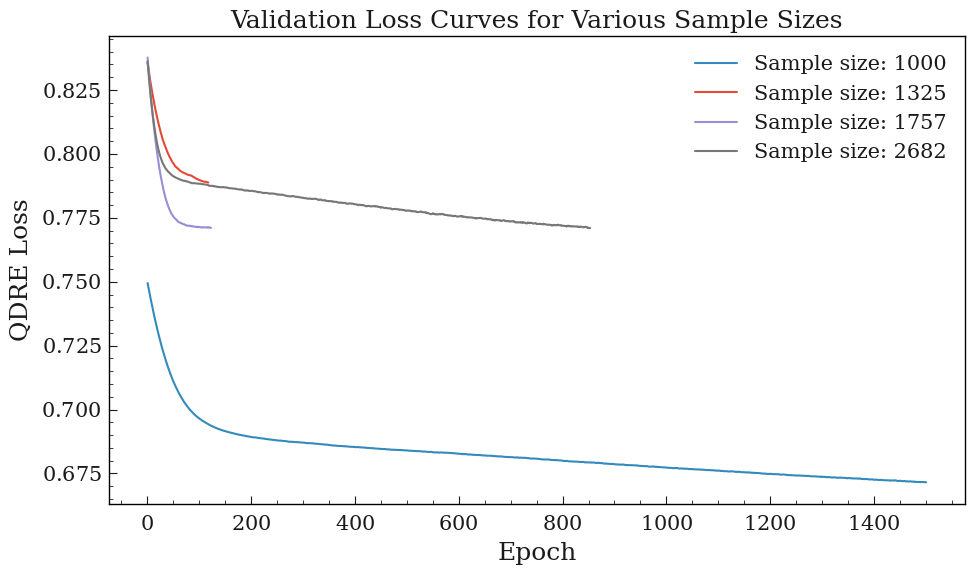

In [5]:
fig,ax = plt.subplots()
fig.set_size_inches(10,6)

starting_epoch = 0

max_epochs = 0
# Get the MC results
for i, mc_training_settings in enumerate(mc_training_settings_list):
    mc_training_losses = mc_training_settings["training_losses"]
    mc_validation_losses = mc_training_settings["validation_losses"]

    mc_validation_loss_per_epoch = np.array(mc_validation_losses[starting_epoch:]).mean(axis=1)
    mc_validation_std_per_epoch = np.array(mc_validation_losses[starting_epoch:]).std(axis=1)

    mc_validation_lower_bar = mc_validation_loss_per_epoch - mc_validation_std_per_epoch
    mc_validation_upper_bar = mc_validation_loss_per_epoch + mc_validation_std_per_epoch
    
    mc_t = np.arange(len(mc_validation_loss_per_epoch)) + 1
    max_epochs = max([max_epochs, len(mc_t)])

    ax.plot(mc_t, mc_validation_loss_per_epoch, label="Sample size: {:d}".format(int(sample_arr[sample_ixs[i]])))


#ax.plot(np.array([starting_epoch, max_epochs-1])+1,
#        [mc_training_settings_list[0]["optimal_valid_loss"]]*2, '--', label="Optimal")

ax.legend(prop={'size': 15})
ax.set_xlabel("Epoch")
ax.set_ylabel("QDRE Loss")
ax.set_title("Validation Loss Curves for Various Sample Sizes")


fig.tight_layout()
#fig.savefig("Validation_loss_curves.pdf")

# Look at overall results across all MC trained classifiers

In [28]:
def get_convergence_auc_and_bias(q, sample_ix, model_path):
    try:
        training_settings = utils.train.load_training_settings(model_path)
    except:
        print("Error loading file: {}".format(model_path))
        return None
    val_losses = np.array(training_settings["validation_losses"]).mean(axis=1)
    val_losses = abs(val_losses - training_settings["optimal_valid_loss"])

    x_arr = np.arange(len(val_losses))+1
    q.put((sample_ix, np.trapz(val_losses - val_losses[-1], x_arr), val_losses[-1]))
    return None

In [29]:
convergence_auc = np.empty((N_SAMPLE_POINTS,))
bias_arr = np.empty((N_SAMPLE_POINTS,))
convergence_auc[:] = np.nan
bias_arr[:] = np.nan

mixture_convergence_auc = np.empty((N_SAMPLE_POINTS,))
mixture_bias_arr = np.empty((N_SAMPLE_POINTS,))
mixture_convergence_auc[:] = np.nan
mixture_bias_arr[:] = np.nan

In [30]:
# Create a queue to store the results
my_queue = mp.Queue()

# Create all of the subprocesses
num_processes = 25
for i in tqdm(range(int(np.ceil(N_SAMPLE_POINTS / num_processes)))):
    processes = []
    for sample_ix in range(int(num_processes*i), min([int(num_processes*(i+1)), N_SAMPLE_POINTS])):
        #sample_ix = i*num_processes + j
        model_path = osp.join("/data/mdrnevich/ml4nw/NegSampleStudy/models/classifier_batch{}_sample{}.zip".format(batch_size, sample_ix))
        processes.append(mp.Process(target=get_convergence_auc_and_bias,
                                    args=(my_queue, sample_ix, model_path)))
        processes[-1].start()
    # Wait for them to finish before starting new ones
    for p in processes:
        p.join()

    for _ in range(N_SAMPLE_POINTS):
        try:
            k, auc, bias = my_queue.get_nowait()
            convergence_auc[k] = auc
            bias_arr[k] = bias
        except queue.Empty:
            break

  0%|          | 0/2 [00:00<?, ?it/s]

In [25]:
# Create a queue to store the results
my_queue = mp.Queue()

# Create all of the subprocesses
num_processes = 25
for i in tqdm(range(int(np.ceil(N_SAMPLE_POINTS / num_processes)))):
    processes = []
    for sample_ix in range(int(num_processes*i), min([int(num_processes*(i+1)), N_SAMPLE_POINTS])):
        #sample_ix = i*num_processes + j
        model_path = osp.join("/data/mdrnevich/ml4nw/NegSampleStudy/models/classifier_SMM_batch{}_sample{}.zip".format(batch_size, sample_ix))
        processes.append(mp.Process(target=get_convergence_auc_and_bias,
                                    args=(my_queue, sample_ix, model_path)))
        processes[-1].start()
    # Wait for them to finish before starting new ones
    for p in processes:
        p.join()
    
    for _ in range(N_SAMPLE_POINTS):
        try:
            k, auc, bias = my_queue.get_nowait()
            mixture_convergence_auc[k] = auc
            mixture_bias_arr[k] = bias
        except queue.Empty:
            break

  0%|          | 0/2 [00:00<?, ?it/s]

Process Process-501:
Traceback (most recent call last):
  File "/home/mdrnevich/miniconda3/envs/carl-for-agc/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/mdrnevich/miniconda3/envs/carl-for-agc/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_330/3150503656.py", line 7, in get_convergence_auc_and_bias
    val_losses = np.array(training_settings["validation_losses"]).mean(axis=1)
                          ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
KeyError: 'validation_losses'
Process Process-507:
Traceback (most recent call last):
  File "/home/mdrnevich/miniconda3/envs/carl-for-agc/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/mdrnevich/miniconda3/envs/carl-for-agc/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Process Process-502:
Process Process-50

In [31]:
convergence_auc

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [26]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

ax.scatter(sample_arr, convergence_auc, color='tab:blue')

ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_ylabel("VLC AUC")
ax.set_title("VLC AUC vs Sample Size")
fig.tight_layout()
ax.set_xscale('log')
#fig.savefig("vlrc_vs_eta_plot.pdf")

Error in callback <function _draw_all_if_interactive at 0x7efb3b2f1260> (for post_execute):


ValueError: Data has no positive values, and therefore can not be log-scaled.

ValueError: Data has no positive values, and therefore can not be log-scaled.

<Figure size 1000x600 with 1 Axes>

0.23100190217892833 0.8931406806703598


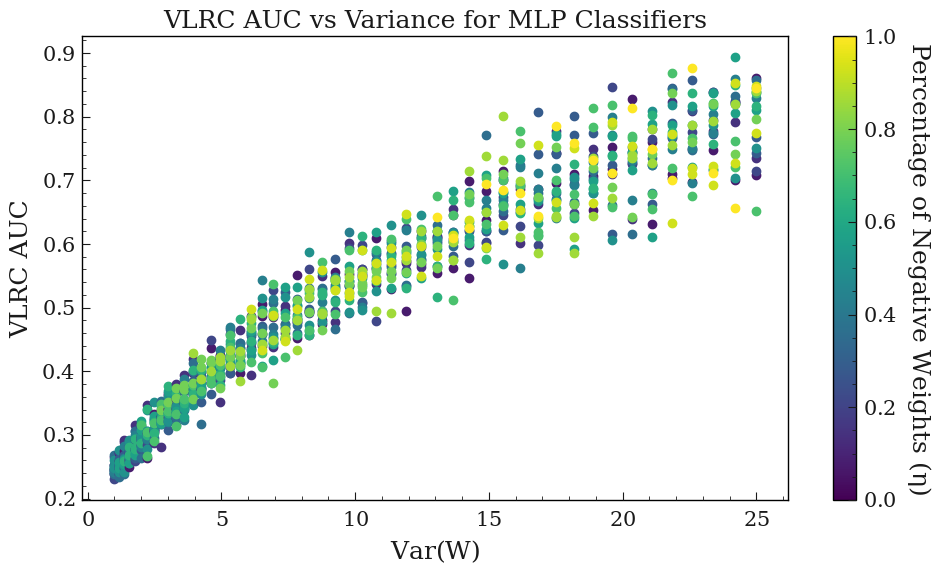

In [42]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(convergence_auc[~np.isnan(convergence_auc)], 1e-1),
                            np.percentile(convergence_auc[~np.isnan(convergence_auc)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(convergence_auc[i,j]) and (convergence_auc[i,j] >= lower_bound) and (convergence_auc[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i]**2)
            y_arr.append(convergence_auc[i,j])
            ax.scatter(sigma_arr[i]**2, convergence_auc[i,j], color=color)


cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

ax.set_xlabel("Var$(W)$")
ax.set_ylabel("VLRC AUC")
ax.set_title("VLRC AUC vs Variance for MLP Classifiers")

#ax.set_ylim(top=2e-3)
fig.tight_layout()
fig.savefig("vlrc_vs_var_plot.pdf")

0.23100190217892833 0.8931406806703598


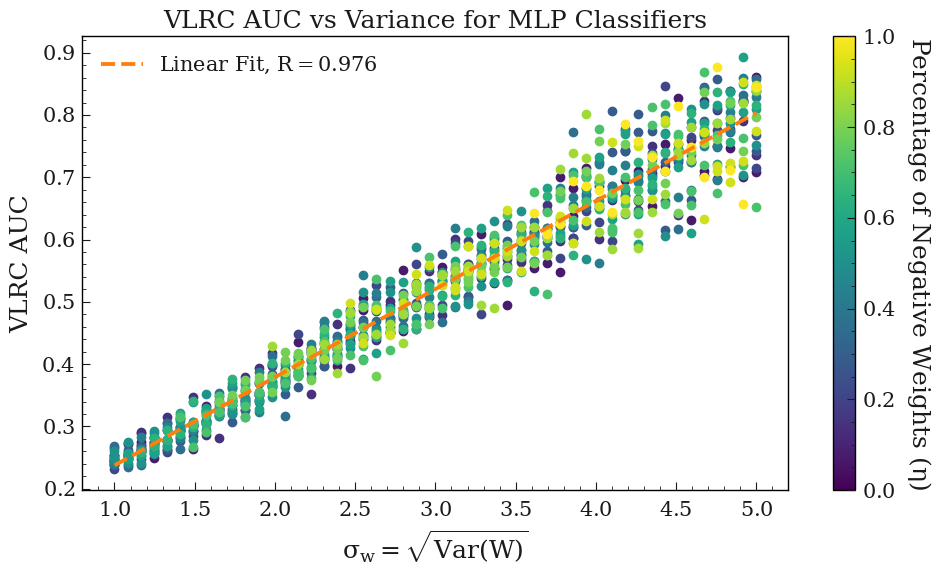

In [76]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(convergence_auc[~np.isnan(convergence_auc)], 1e-1),
                            np.percentile(convergence_auc[~np.isnan(convergence_auc)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"] #mpl.colormaps["cividis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(convergence_auc[i,j]) and (convergence_auc[i,j] >= lower_bound) and (convergence_auc[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i])
            y_arr.append(convergence_auc[i,j])
            ax.scatter(sigma_arr[i], convergence_auc[i,j], color=color)


#exp_p = lambda x, n, a, b: a*np.power(x, n) + b
#exp_params = sp.optimize.curve_fit(exp_p, x_arr, y_arr, (1/2, 1, 0))[0]

exp_p = lambda x, a,b: a*x + b
exp_params = sp.optimize.curve_fit(exp_p, x_arr, y_arr, (1, 0), maxfev=int(1e5))[0]

#ax.plot(sigma_arr, exp_p(sigma_arr, *exp_params), '--', c='tab:red', label="O$(x^{" +"{:.3f}".format(exp_params[0])+"})$")
ax.plot(sigma_arr, exp_p(sigma_arr, *exp_params), '--', c='tab:orange', label="Linear Fit, $R = {:.3f}$".format(np.corrcoef(x_arr,y_arr)[0,1]), linewidth=2.75)
#ax.plot([], [], ' ', label="$R = {:.3f}$".format(np.corrcoef(x_arr,y_arr)[0,1]))


cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

ax.legend(fontsize=15)
ax.set_xlabel("$\sigma_w = \sqrt{Var(W)}$")
ax.set_ylabel("VLRC AUC")
ax.set_title("VLRC AUC vs Variance for MLP Classifiers")

#ax.set_ylim(top=2e-3)
fig.tight_layout()
fig.savefig("vlrc_vs_var_plot.pdf")

0.23100190217892833 0.8931406806703598
Exponential Parameters: 5.03E-01, 1.40E-01, 9.81E-02


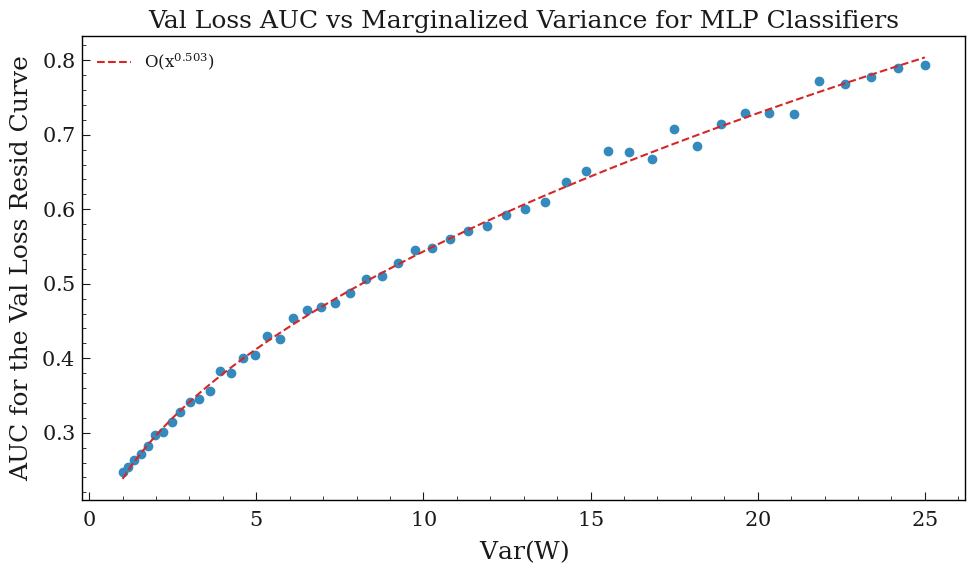

In [44]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(convergence_auc[~np.isnan(convergence_auc)], 1e-1),
                            np.percentile(convergence_auc[~np.isnan(convergence_auc)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_auc_arr = np.copy(convergence_auc)
marginal_auc_arr[(convergence_auc < lower_bound)|(convergence_auc > upper_bound)] = np.nan
marginal_auc_arr = np.nanmean(marginal_auc_arr, axis=1)
good_ix = ~np.isnan(marginal_auc_arr)

ax.scatter(sigma_arr**2, marginal_auc_arr)

exp_p = lambda x, n, a, b: a*np.power(x, n) + b
exp_params = sp.optimize.curve_fit(exp_p, sigma_arr[good_ix]**2, marginal_auc_arr[good_ix], (1/2, 1, 0))[0]


print("Exponential Parameters: {:.2E}, {:.2E}, {:.2E}".format(*exp_params))


ax.plot(sigma_arr**2, exp_p(sigma_arr**2, *exp_params), '--', c='tab:red', label="O$(x^{" +"{:.3f}".format(exp_params[0])+"})$")

ax.legend()
ax.set_xlabel("Var$(W)$")
ax.set_ylabel("AUC for the Val Loss Resid Curve")
ax.set_title("Val Loss AUC vs Marginalized Variance for MLP Classifiers")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()

## Now look at bias

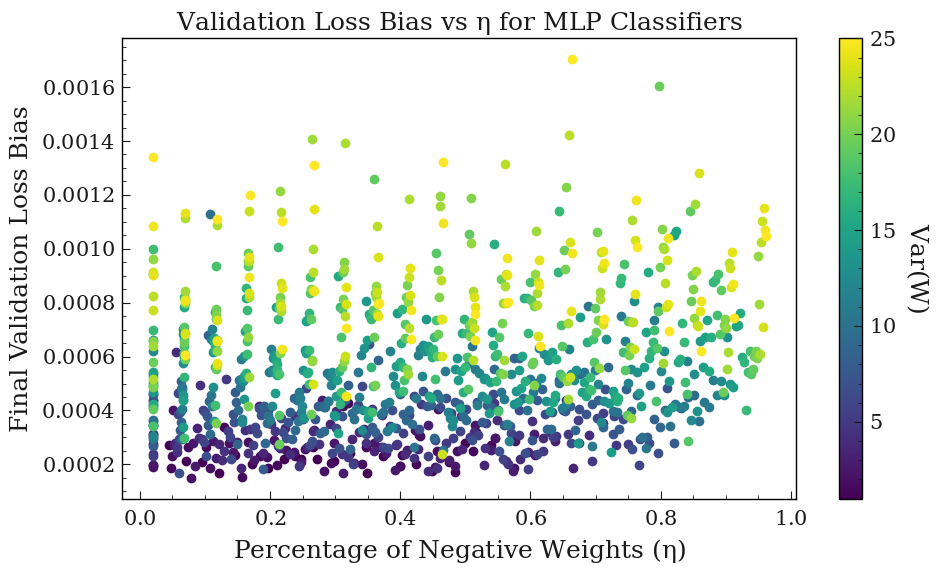

In [45]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_SIGMA))

for i in range(N_SIGMA):
    ax.scatter(eta_arr[i], bias_arr[i], color=colors[i])

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=sigma_arr.min()**2, vmax=sigma_arr.max()**2),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Var$(W)$", rotation=-90, va="bottom")

ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs $\eta$ for MLP Classifiers")
fig.tight_layout()

0.0001523828485298344 0.001605156231953535


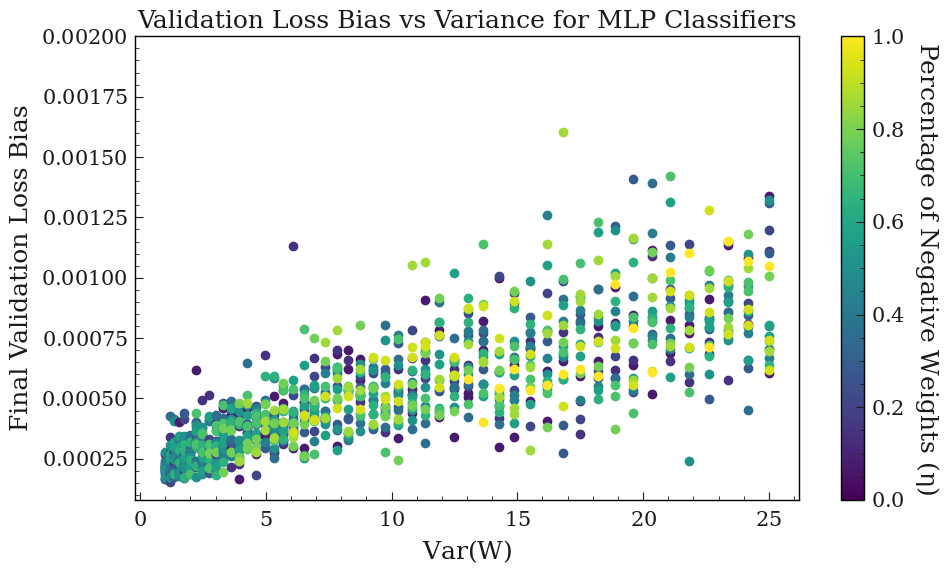

In [46]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(bias_arr[~np.isnan(bias_arr)], 1e-1),
                            np.percentile(bias_arr[~np.isnan(bias_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(bias_arr[i,j]) and (bias_arr[i,j] >= lower_bound) and (bias_arr[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i]**2)
            y_arr.append(bias_arr[i,j])
            ax.scatter(sigma_arr[i]**2, bias_arr[i,j], color=color)


cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

ax.set_xlabel("Var$(W)$")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs Variance for MLP Classifiers")

ax.set_ylim(top=2e-3)
fig.tight_layout()

0.0001523828485298344 0.001605156231953535
Exponential Parameters: 6.92E-01, 8.18E-05, 1.51E-04


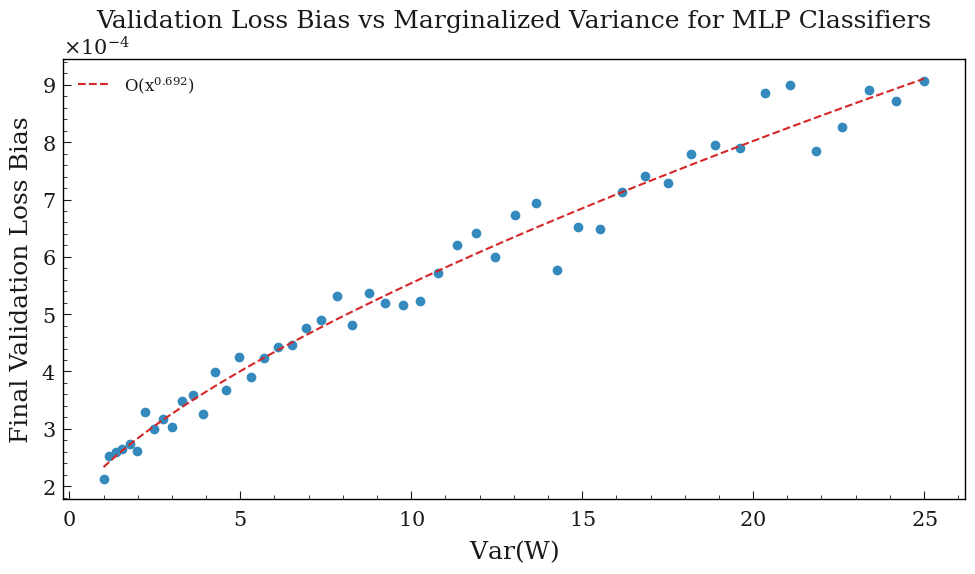

In [47]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(bias_arr[~np.isnan(bias_arr)], 1e-1),
                            np.percentile(bias_arr[~np.isnan(bias_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_bias_arr = np.copy(bias_arr)
marginal_bias_arr[(bias_arr < lower_bound)|(bias_arr > upper_bound)] = np.nan
marginal_bias_arr = np.nanmean(marginal_bias_arr, axis=1)
good_ix = ~np.isnan(marginal_bias_arr)

ax.scatter(sigma_arr**2, marginal_bias_arr)

exp_p = lambda x, n, a, b: a*np.power(x, n) + b
exp_params = sp.optimize.curve_fit(exp_p, sigma_arr[good_ix]**2, marginal_bias_arr[good_ix], (1/2, 1, 1))[0]


print("Exponential Parameters: {:.2E}, {:.2E}, {:.2E}".format(*exp_params))


ax.plot(sigma_arr**2, exp_p(sigma_arr**2, *exp_params), '--', c='tab:red', label="O$(x^{" +"{:.3f}".format(exp_params[0])+"})$")

ax.legend()
ax.set_xlabel("Var$(W)$")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs Marginalized Variance for MLP Classifiers")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()

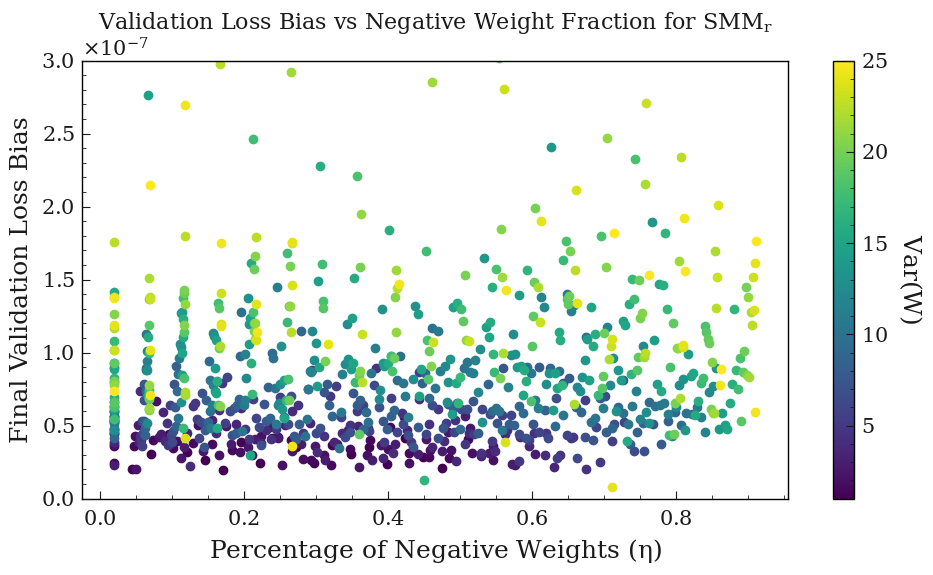

In [53]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_SIGMA))

for i in range(N_SIGMA):
    ax.scatter(eta_arr[i], mixture_bias_arr[i], color=colors[i])

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=sigma_arr.min()**2, vmax=(sigma_arr.max())**2),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Var$(W)$", rotation=-90, va="bottom")

ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs Negative Weight Fraction for $SMM_r$", fontsize=16)
ax.set_ylim([0, 3e-7])
fig.tight_layout()

1.2403223391688202e-08 2.786307054969404e-07


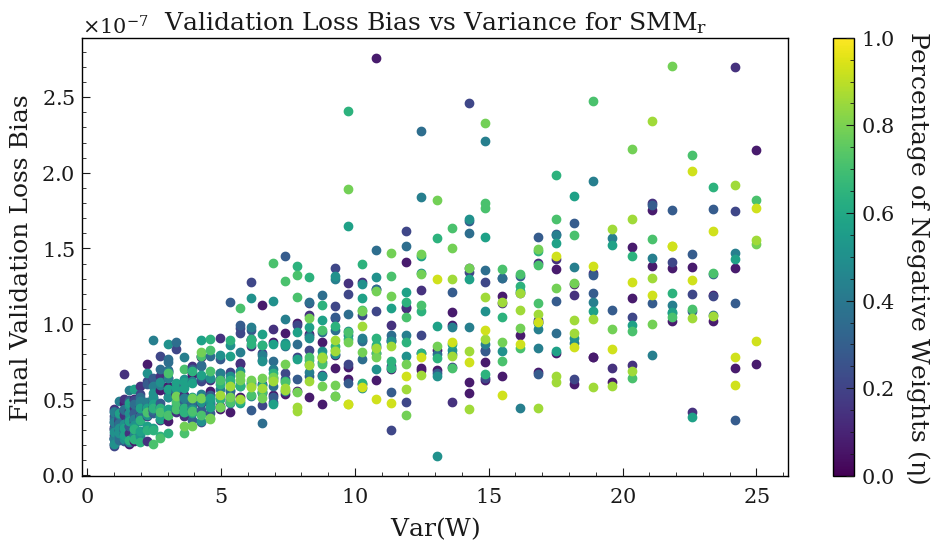

In [32]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(mixture_bias_arr[~np.isnan(mixture_bias_arr)], 1e-1),
                            np.percentile(mixture_bias_arr[~np.isnan(mixture_bias_arr)], 85))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(mixture_bias_arr[i,j]) and (mixture_bias_arr[i,j] >= lower_bound) and (mixture_bias_arr[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i]**2)
            y_arr.append(mixture_bias_arr[i,j])
            ax.scatter(sigma_arr[i]**2, mixture_bias_arr[i,j], color=color)


cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

ax.set_xlabel("Var$(W)$")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs Variance for $SMM_r$")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()

1.2403223391688202e-08 2.786307054969404e-07
Exponential Parameters: 4.37E-01, 3.55E-08, -5.90E-09


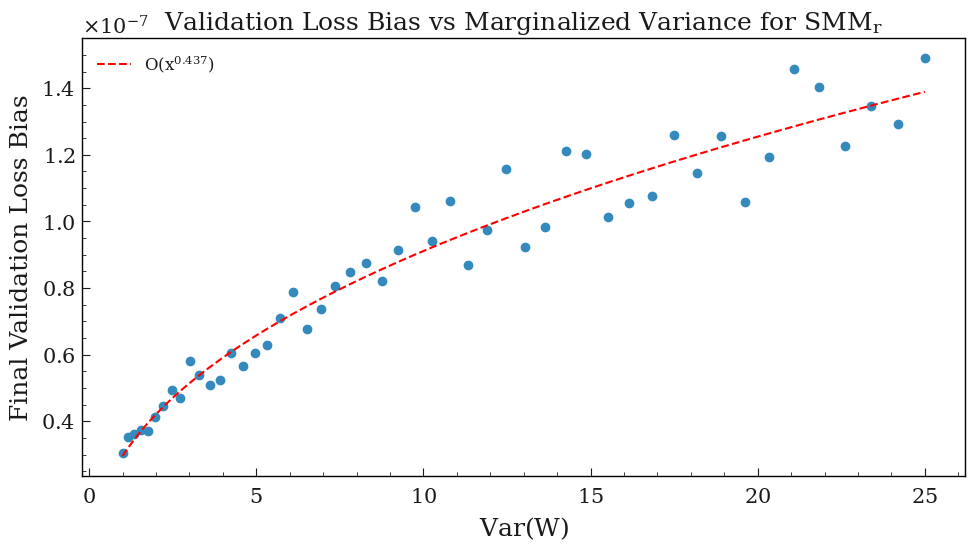

In [31]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

lower_bound, upper_bound = (np.percentile(mixture_bias_arr[~np.isnan(mixture_bias_arr)], 1e-1),
                            np.percentile(mixture_bias_arr[~np.isnan(mixture_bias_arr)], 85))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["cividis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_mixture_bias_arr = np.copy(mixture_bias_arr)
marginal_mixture_bias_arr[(mixture_bias_arr < lower_bound)|(mixture_bias_arr > upper_bound)] = np.nan
marginal_mixture_bias_arr = np.nanmean(marginal_mixture_bias_arr, axis=1)
good_ix = ~np.isnan(marginal_mixture_bias_arr)


ax.scatter(sigma_arr**2, marginal_mixture_bias_arr)


exp_p = lambda x, n, a, b: a*np.power(x, n) + b
mixture_exp_params = sp.optimize.curve_fit(exp_p, sigma_arr[good_ix]**2, marginal_mixture_bias_arr[good_ix], (1/2, 1, 0), maxfev=int(1e5))[0]

print("Exponential Parameters: {:.2E}, {:.2E}, {:.2E}".format(*mixture_exp_params))


ax.plot(sigma_arr**2, exp_p(sigma_arr**2, *mixture_exp_params), '--', c='red', label="O$(x^{" +"{:.3f}".format(mixture_exp_params[0])+"})$")

ax.legend()
ax.set_xlabel("Var$(W)$")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs Marginalized Variance for $SMM_r$")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()

### Compare the rate of growth with variance for the basic classifier and mixture model

In [26]:
exp_params[0], mixture_exp_params[0]

(0.6923325887254379, 0.43723167863413465)

# Now look at performance metrics

### Submit batch jobs to run `evaluate_classifiers.py`

In [10]:
import torch
import torch.nn.functional as F

from utils import preprocessing as carl_preprocessing
from utils import models as carl_models
from utils import train as carl_train

import torch.multiprocessing as tmp
#try:
#tmp.set_start_method('spawn', force=True)
#except RuntimeError:
#    pass

@torch.no_grad()
def test_mix(model, loader, weight_norm=1, regularizer=False, max_num_batches=np.inf,
             regularization=0.0, progress_bar=True, leave=False, loss="qdre", device='cpu'):
    loader.collate_fn = lambda batch: carl_preprocessing.prep_inputs_for_training_mix(batch, weight_norm=weight_norm)
    batch_losses = []

    sum_loss = 0.0
    if progress_bar is True:
        t = tqdm(enumerate(loader), total=len(loader), position=0, leave=leave)
    else:
        t = enumerate(loader)
    for i, batch in t:
        if i+1 >= max_num_batches:
            break
        x = batch[0]
        y = batch[1]
        w = batch[2]

        classname = model.__class__.__name__
        STANDARD_CLASSIFIERS = ["Classifier", "Regression"]
        MIXTURE_CLASSIFIERS = ["MixtureClassifier", "SingleMixtureClassifier"]

        if classname in STANDARD_CLASSIFIERS:
            batch_output = model(x).reshape(-1,1)
        elif classname in MIXTURE_CLASSIFIERS:
            batch_output = model(x, score_function=loss).reshape(-1,1)
        elif type(model) is types.FunctionType:
            batch_output = model(x).reshape(-1,1)

        if loss == 'bce':
            batch_loss_item = F.binary_cross_entropy(batch_output, y, weight=w).cpu().item()
        elif loss == 'qdre':
            batch_loss_item = (carl_train.qdre_loss(batch_output, y, reduction='none')*w).mean().cpu().item()
        else:
            raise Exception("Loss not implemented")
        batch_losses.append(batch_loss_item)
        sum_loss += batch_loss_item
        if progress_bar is True:
            t.set_description("loss = %.5f" % (batch_loss_item))
            t.refresh()  # to show immediately the update

    return batch_losses, sum_loss / (i + 1)

@torch.no_grad()
def get_scores(model, loader, X_scaler=None, weight_norm=1, mix=False, leave=False, calibrator=None):
    if type(model) is not types.FunctionType:
        model.eval()
        if mix is True:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training_mix(batch, weight_norm=weight_norm)
        else:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training(batch, X_scaler, weight_norm=weight_norm)
    else:
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_density(batch, weight_norm=weight_norm)

    score_list = []
    target_list = []
    weight_list = []
    #t = tqdm(enumerate(loader), total=len(loader), leave=leave)
    for i, batch in enumerate(loader):
        target_list.append(batch[1])
        weight_list.append(batch[2])
        if type(model) is not types.FunctionType:
            x = batch[0].to(DEVICE)
        else:
            x = batch[0].to('cpu')
        batch_score = model(x)
        if calibrator is not None:
            batch_score = calibrator.predict(batch_score.cpu())
        score_list.append(batch_score)
        #t.refresh()  # to show immediately the update

    if calibrator is None:
        score_list = torch.cat(score_list).cpu().numpy().flatten()
    else:
        score_list = np.concatenate(score_list).flatten()
    return score_list, torch.cat(target_list).cpu().numpy().flatten(), torch.cat(weight_list).cpu().numpy().flatten()


"""
@torch.no_grad()
def get_r_hats(model, loader, X_scaler=None, weight_norm=1, mix=False, leave=False):
    if type(model) is not types.FunctionType:
        model.eval()
        if mix is True:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training_mix(batch, weight_norm=weight_norm)
        else:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training(batch, X_scaler, weight_norm=weight_norm)
    else:
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_density(batch, weight_norm=weight_norm)

    r_hat_list = []
    t = tqdm(enumerate(loader), total=len(loader), leave=leave)
    for i, batch in t:
        if type(model) is not types.FunctionType:
            x = batch[0].to(DEVICE)
        else:
            x = batch[0].to('cpu')
        batch_output = model(x)
        r_hat = batch_output / (1 - batch_output)
        r_hat_list.append(r_hat)
        t.refresh()  # to show immediately the update

    return torch.cat(r_hat_list).cpu().numpy().flatten()
"""


@torch.no_grad()
def get_r_hats(model, loader, X_scaler=None, weight_norm=1, mix=False, leave=False, loss="qdre", t0=None, t1=None):
    if type(model) is not types.FunctionType:
        model.eval()
        if mix is True:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training_mix(batch, weight_norm=weight_norm)
        else:
            loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training(batch, X_scaler, weight_norm=weight_norm)
    else:
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_density(batch, weight_norm=weight_norm)

    r_hat_list = []
    t = tqdm(enumerate(loader), total=len(loader), leave=leave)
    for i, batch in t:
        if type(model) is not types.FunctionType:
            x = batch[0].to(DEVICE)
        else:
            x = batch[0].to('cpu')
        
        if mix is True:
            r_hat = model.ratio(x)
        else:
            batch_output = model(x)
            if loss in ["bce", "mse"]:
                r_hat = batch_output / (1 - batch_output)
            elif loss == "pare":
                r_hat = - t0*(1- t0*batch_output)/(t1*(1 - t1*batch_output))
            elif loss == 'qdre':
                r_hat = (1-2*batch_output) / (batch_output - batch_output**2)
        r_hat_list.append(r_hat)
        t.refresh()  # to show immediately the update

    return torch.cat(r_hat_list).cpu().numpy().flatten()



def get_r(batch_list):
    x_batch_list = []
    w_batch_list = []
    for sample in batch_list:
        x_batch_list.append(sample[0])
        w_batch_list.append(sample[2])
    x_batch = torch.stack(x_batch_list)
    r_batch = np.sqrt(x_batch[:,0]**2 + x_batch[:,1]**2).reshape(-1, 1)
    w_batch = torch.stack(w_batch_list)
    return r_batch, w_batch


@torch.no_grad()
def get_plot_data(loader):
    temp_x = []
    temp_w = []
    t = tqdm(enumerate(loader), total=len(loader))
    for i, batch in t:
        temp_x.append(batch[0])
        temp_w.append(batch[1])
        t.refresh()  # to show immediately the update
    return torch.cat(temp_x).numpy().flatten(), torch.cat(temp_w).numpy().flatten()

In [11]:
source_file = "/data/mdrnevich/ml4nw/NegSampleStudy/base_distribution_data"
target_file = "/data/mdrnevich/ml4nw/NegSampleStudy/target_distribution_data"

test_base_dataset = utils.preprocessing.Dataset(source_file + "_test.npy", 0)
test_target_dataset = utils.preprocessing.Dataset(target_file + "_test.npy", 1)

test_base_dataset.process(normalize_weights=True)
test_target_dataset.process(normalize_weights=True)

test_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(test_base_dataset), batch_size=batch_size, shuffle=False)
test_target_loader = DataLoader(utils.preprocessing.CombinedDataset(test_target_dataset), batch_size=batch_size, shuffle=False)

test_nominal_loader.collate_fn = lambda batch: get_r(batch)
test_target_loader.collate_fn = lambda batch: get_r(batch)

test_nominal_r = get_plot_data(test_nominal_loader)
test_target_r = get_plot_data(test_target_loader)

optimal_ratios = get_r_hats(
    s_optimal,
    test_nominal_loader,
    mix=False,
    leave=False
)

optimal_divergence = utils.plotting.Tsallis_KL(test_target_r[0], test_target_r[1], test_nominal_r[0], test_nominal_r[1]*optimal_ratios, np.linspace(0, 8, 150))
optimal_divergence

  0%|          | 0/13672 [00:00<?, ?it/s]

  0%|          | 0/13672 [00:00<?, ?it/s]

  0%|          | 0/13672 [00:00<?, ?it/s]

0.00080861896

In [14]:
optimal_test_loss = test_mix(
    s_optimal,
    test_loader,
    weight_norm=1, #pos_weight_norm,
    leave=False,
    device=DEVICE
)[1]
optimal_test_loss

  0%|          | 0/6836 [00:00<?, ?it/s]

0.8985007919453961

In [51]:
roc_auc_arr = np.zeros((N_SAMPLE_POINTS,))
test_loss_arr = np.zeros((N_SAMPLE_POINTS,))

roc_auc_arr = np.empty((N_SAMPLE_POINTS,))
test_loss_arr = np.empty((N_SAMPLE_POINTS,))
div_arr = np.empty((N_SAMPLE_POINTS,))
roc_auc_arr[:] = np.nan
test_loss_arr[:] = np.nan
div_arr[:] = np.nan

mixture_roc_auc_arr = np.empty((N_SAMPLE_POINTS,))
mixture_test_loss_arr = np.empty((N_SAMPLE_POINTS,))
mixture_div_arr = np.empty((N_SAMPLE_POINTS,))
mixture_roc_auc_arr[:] = np.nan
mixture_test_loss_arr[:] = np.nan
mixture_div_arr[:] = np.nan

In [52]:
for i in range(N_SAMPLE_POINTS):
    try:
        results = np.load("/data/mdrnevich/ml4nw/NegSampleStudy/temp/results_{}.npy".format(i))
        #roc_auc = results[2]
        test_loss = abs(results[1] - optimal_test_loss)
        div = results[2]
    except FileNotFoundError:
        continue
    #roc_auc_arr[i,j] = roc_auc
    test_loss_arr[i] = test_loss
    div_arr[i] = div

In [58]:
for i in range(N_SAMPLE_POINTS):
    try:
        results = np.load("/data/mdrnevich/ml4nw/NegSampleStudy/temp/results_SMM_{}.npy".format(i))
        #roc_auc = results[2]
        test_loss = abs(results[1] - optimal_test_loss)
        div = results[2]
        print(test_loss, div)
    except FileNotFoundError:
        continue
    #mixture_roc_auc_arr[i,j] = roc_auc
    mixture_test_loss_arr[i] = test_loss
    mixture_div_arr[i] = div

0.010869284129372936 1.4357796907424927
0.010593101242747816 0.8853005170822144
0.008339153165667912 0.3802088499069214
0.009674227977963912 0.39796435832977295
0.008762468465627227 0.49906718730926514
inf 0.16186277568340302
0.0027970664285998925 0.07942117750644684
0.004682181098957794 0.9645136594772339
0.008172681447251473 0.2023950070142746
0.002799028603740372 0.008478237316012383
0.0028320698099152386 0.006627887487411499
0.0030685598395803204 0.040885426104068756
0.003854551458826072 0.02551192417740822
nan 0.0027066273614764214
0.001887683084723868 0.048099637031555176
0.0022390157620832962 0.014664905145764351
inf 0.028709791600704193
0.0012035567755933618 0.021548062562942505
0.0009955068850739934 0.008427748456597328
0.0014639139968863901 0.2686988413333893
0.0008820464617679269 0.006051454693078995
0.0007832784395317427 0.010686968453228474
inf 0.00838913768529892
0.0004413599914594446 0.0019088084809482098
inf 0.011661062948405743
nan 0.0011734513100236654
inf 0.000739925

In [59]:
optimal_divergence

0.00080861896

In [60]:
(div_arr / optimal_divergence), (mixture_div_arr / optimal_divergence)

(array([4.10931301e+01, 6.22522966e+02, 7.63359188e+02, 2.89321576e+02,
        7.03406990e+02, 5.74658715e+01, 6.44032617e+02, 6.87803945e+01,
        5.51492200e+02, 3.06891027e+01, 1.57957726e+01, 4.94828068e+01,
        1.58939842e+01, 1.59593572e+00, 6.03051847e+01, 6.32428868e+00,
        3.22624757e+00, 1.08849384e+01, 2.36273277e+00, 1.02516654e+01,
        4.58692822e+00, 3.19819222e+00, 4.77996379e+00, 6.87522459e-01,
        2.25802363e+00, 2.44944993e+00, 7.81762238e-01, 1.20702668e+00,
        2.40777635e+00, 2.92750631e+00, 5.51432886e+00, 1.09847359e+00,
        6.15982991e-01, 5.38791336e-01, 1.12535819e-01, 6.53188605e+00,
        4.13326607e-02, 3.27967355e-01, 6.75347481e+00, 1.25793552e-01,
        3.73574140e-02, 5.01843943e-01, 4.11468267e-01, 1.96855723e+00,
        4.86976071e-01, 4.92032806e-01, 8.69617782e+00, 1.97103823e-02,
        4.93518557e-01, 8.10774974e-01]),
 array([1.77559488e+03, 1.09483027e+03, 4.70195317e+02, 4.92153136e+02,
        6.17184620e+02

# Look at the ROC AUC Metric and Trends

In [41]:
"""fig, ax = plt.subplots()
fig.set_size_inches(10,6)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_SIGMA))

for i in range(N_SIGMA):
    ax.scatter(eta_arr[i], roc_auc_arr[i], color=colors[i])

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=sigma_arr.min()**2, vmax=sigma_arr.max()**2),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Var$(W)$", rotation=-90, va="bottom")

ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_ylabel("ROC AUC Score")
ax.set_title("ROC AUC Score vs $\eta$ for MLP Classifiers")
fig.tight_layout()""";

In [42]:
"""fig, ax = plt.subplots()
fig.set_size_inches(10,6)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_SIGMA))

for i in range(N_SIGMA):
    ax.scatter(eta_arr[i], mixture_roc_auc_arr[i], color=colors[i])

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=sigma_arr.min()**2, vmax=sigma_arr.max()**2),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Var$(W)$", rotation=-90, va="bottom")

ax.set_ylim([0.603, 0.609])
ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_ylabel("ROC AUC Score")
ax.set_title("ROC AUC Score vs $\eta$ for $SMM_r$")
fig.tight_layout()""";

## Look at the ROC AUC growth for the two types of models

In [43]:
"""fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(roc_auc_arr[~np.isnan(roc_auc_arr)], 1e-1),
                            np.percentile(roc_auc_arr[~np.isnan(roc_auc_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(roc_auc_arr[i,j]) and (roc_auc_arr[i,j] >= lower_bound) and (roc_auc_arr[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i]**2)
            y_arr.append(roc_auc_arr[i,j])
            ax.scatter(sigma_arr[i]**2, roc_auc_arr[i,j], color=color)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

ax.set_xlabel("Var$(W)$")
ax.set_ylabel("ROC AUC Score")
ax.set_title("ROC AUC Score vs Variance for MLP Classifiers")

#ax.set_ylim(top=2e-3)
fig.tight_layout()""";

In [44]:
"""fig, ax = plt.subplots()
fig.set_size_inches(10,6)

x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(roc_auc_arr[~np.isnan(roc_auc_arr)], 1e-1),
                            np.percentile(roc_auc_arr[~np.isnan(roc_auc_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["cividis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_roc_auc_arr = np.copy(roc_auc_arr)
marginal_roc_auc_arr[(roc_auc_arr < lower_bound)|(roc_auc_arr > upper_bound)] = np.nan
marginal_roc_auc_arr = np.nanmean(marginal_roc_auc_arr, axis=1)
good_ix = ~np.isnan(marginal_roc_auc_arr)

ax.scatter(sigma_arr**2, marginal_roc_auc_arr)

exp_p = lambda x, n, a, b, c: a*np.power(x-b, n) + c

exp_params = sp.optimize.curve_fit(exp_p, sigma_arr[good_ix]**2, marginal_roc_auc_arr[good_ix], (1/2, 1, 0, 0), maxfev=int(1e5))[0]

poly_params = np.polyfit(sigma_arr[good_ix]**2, marginal_roc_auc_arr[good_ix], 2)
p = np.poly1d(poly_params)

print("Polynomial Parameters: {:.2E}, {:.2E}, {:.2E}".format(*poly_params))
print("Exponential Parameters: {:.2E}, {:.2E}, {:.2E}, {:.2E}".format(*exp_params))


ax.plot(sigma_arr**2, p(sigma_arr**2), '--', label="Poly Fit")
ax.plot(sigma_arr**2, exp_p(sigma_arr**2, *exp_params), '--', label="Exp Fit")

ax.legend()
ax.set_xlabel("Var$(W)$")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs Marginalized Variance for MLP Classifiers")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()""";

In [45]:
"""fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(mixture_roc_auc_arr[~np.isnan(mixture_roc_auc_arr)], 6e0),
                            np.percentile(mixture_roc_auc_arr[~np.isnan(mixture_roc_auc_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(mixture_roc_auc_arr[i,j]) and (mixture_roc_auc_arr[i,j] >= lower_bound) and (mixture_roc_auc_arr[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i]**2)
            y_arr.append(mixture_roc_auc_arr[i,j])
            ax.scatter(sigma_arr[i]**2, mixture_roc_auc_arr[i,j], color=color)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

ax.set_xlabel("Var$(W)$")
ax.set_ylabel("ROC AUC Score")
ax.set_title("ROC AUC Score vs Variance for $SMM_r$")

#ax.set_ylim(top=2e-3)
fig.tight_layout()""";

In [46]:
"""fig, ax = plt.subplots()
fig.set_size_inches(10,6)

x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(mixture_roc_auc_arr[~np.isnan(mixture_roc_auc_arr)], 6e0),
                            np.percentile(mixture_roc_auc_arr[~np.isnan(mixture_roc_auc_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_mixture_roc_auc_arr = np.copy(mixture_roc_auc_arr)
marginal_mixture_roc_auc_arr[(mixture_roc_auc_arr < lower_bound)|(mixture_roc_auc_arr > upper_bound)] = np.nan
marginal_mixture_roc_auc_arr = np.nanmean(marginal_mixture_roc_auc_arr, axis=1)
good_ix = ~np.isnan(marginal_mixture_roc_auc_arr)

ax.scatter(sigma_arr**2, marginal_mixture_roc_auc_arr)

exp_p = lambda x, n, a, b, c: a*np.power(x-b, n) + c

exp_params = sp.optimize.curve_fit(exp_p, sigma_arr[good_ix]**2, marginal_mixture_roc_auc_arr[good_ix], (1/2, 1, 0, 0), maxfev=int(1e5))[0]

poly_params = np.polyfit(sigma_arr[good_ix]**2, marginal_mixture_roc_auc_arr[good_ix], 2)
p = np.poly1d(poly_params)

print("Polynomial Parameters: {:.2E}, {:.2E}, {:.2E}".format(*poly_params))
print("Exponential Parameters: {:.2E}, {:.2E}, {:.2E}, {:.2E}".format(*exp_params))


ax.plot(sigma_arr**2, p(sigma_arr**2), '--', label="Poly Fit")
ax.plot(sigma_arr**2, exp_p(sigma_arr**2, *exp_params), '--', label="Exp Fit")

ax.legend()
ax.set_xlabel("Var$(W)$")
ax.set_ylabel("Final Validation Loss Bias")
ax.set_title("Validation Loss Bias vs Marginalized Variance for $SMM_r$")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()""";

In [47]:
"""fig, ax = plt.subplots()
fig.set_size_inches(10,6)

lower_bound, upper_bound = (np.percentile(roc_auc_arr[~np.isnan(roc_auc_arr)], 1e-1),
                            np.percentile(roc_auc_arr[~np.isnan(roc_auc_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_roc_auc_arr = np.copy(roc_auc_arr)
marginal_roc_auc_arr[(roc_auc_arr < lower_bound)|(roc_auc_arr > upper_bound)] = np.nan
marginal_roc_auc_arr = np.nanmean(marginal_roc_auc_arr, axis=1)
good_ix = ~np.isnan(marginal_roc_auc_arr)

ax.scatter(sigma_arr**2, marginal_roc_auc_arr, c="tab:blue", alpha=0.75, label="MLP")

exp_p = lambda x, n, a, b, c: a*np.power(x-b, n) + c
exp_params = sp.optimize.curve_fit(exp_p, sigma_arr[good_ix]**2, marginal_roc_auc_arr[good_ix], (1/2, 1, 0, 0), maxfev=int(1e5))[0]
print("Exponential Parameters: {:.2E}, {:.2E}, {:.2E}, {:.2E}".format(*exp_params))

ax.plot(sigma_arr**2, exp_p(sigma_arr**2, *exp_params), '--', c='tab:blue', label="O$(x^{" +"{:.3f}".format(exp_params[0])+"})$")


#######################

ax2 = ax

########################

lower_bound, upper_bound = (np.percentile(mixture_roc_auc_arr[~np.isnan(mixture_roc_auc_arr)], 6e0),
                            np.percentile(mixture_roc_auc_arr[~np.isnan(mixture_roc_auc_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_mixture_roc_auc_arr = np.copy(mixture_roc_auc_arr)
marginal_mixture_roc_auc_arr[(mixture_roc_auc_arr < lower_bound)|(mixture_roc_auc_arr > upper_bound)] = np.nan
marginal_mixture_roc_auc_arr = np.nanmean(marginal_mixture_roc_auc_arr, axis=1)
good_ix = ~np.isnan(marginal_mixture_roc_auc_arr)

ax2.scatter(sigma_arr**2, marginal_mixture_roc_auc_arr, c="tab:orange", alpha=0.75, label="$SMM_r$")

mixture_exp_params = sp.optimize.curve_fit(exp_p, sigma_arr[good_ix]**2, marginal_mixture_roc_auc_arr[good_ix], (1/2, 1, 0, 0), maxfev=int(1e5))[0]
print("Mixture Exponential Parameters: {:.2E}, {:.2E}, {:.2E}, {:.2E}".format(*mixture_exp_params))

ax2.plot(sigma_arr**2, exp_p(sigma_arr**2, *mixture_exp_params), '--', c='tab:orange', label="O$(x^{" +"{:.3f}".format(mixture_exp_params[0])+"})$")
print(mixture_exp_params)


ax.legend()
ax.set_xlabel("Var$(W)$")
ax.set_ylabel("ROC AUC Score")
ax.set_title("ROC AUC Score vs Marginalized Variance")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()
#fig.savefig("variance_growth_comparison.pdf")""";

# Now look at the radial divergence trends

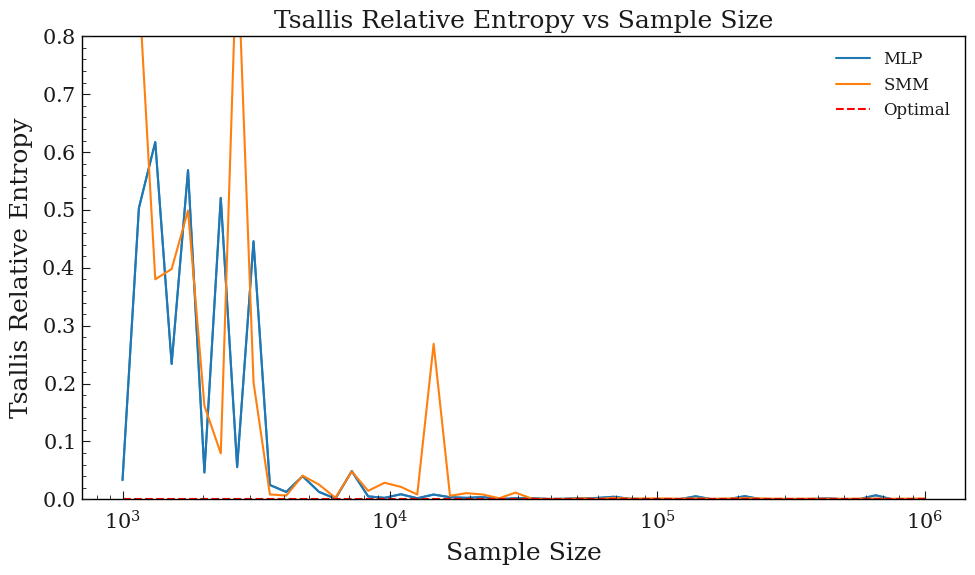

In [63]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)


#ax.plot([0,1],[optimal_divergence]*2, '--', c='red', label="Optimal")

ax.plot(sample_arr, div_arr)
ax.plot(sample_arr, div_arr, c='tab:blue', label="MLP")
ax.plot(sample_arr, mixture_div_arr, c='tab:orange', label="$SMM$")
ax.plot([sample_arr.min(),sample_arr.max()],[optimal_divergence]*2, '--', c='red', label="Optimal")

ax.set_ylim([-1e-5, 8e-1])
ax.legend()
ax.set_xlabel("Sample Size")
ax.set_ylabel("Tsallis Relative Entropy")
ax.set_title("Tsallis Relative Entropy vs Sample Size")
ax.set_xscale('log')
fig.tight_layout()
#fig.savefig("ts_vs_eta_basic_plot.pdf")

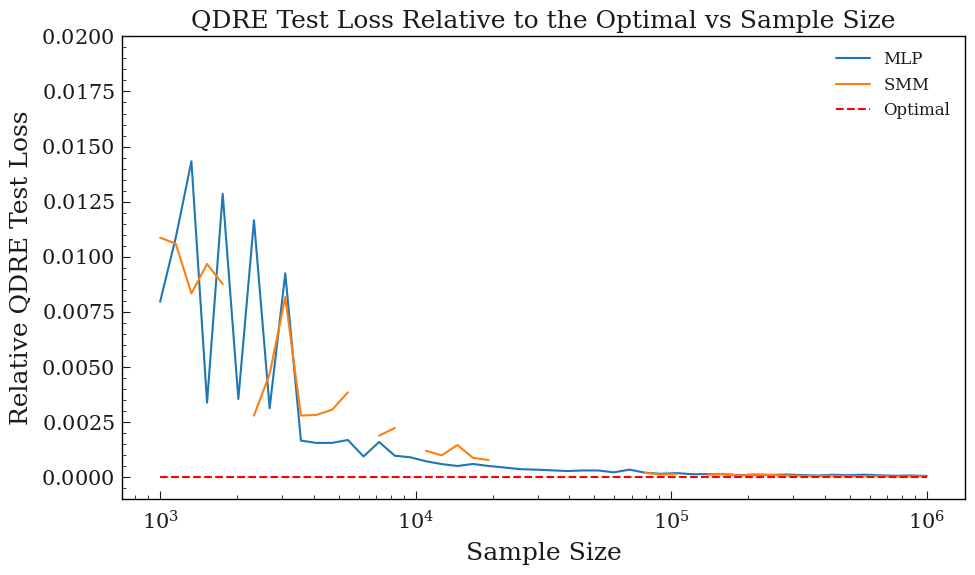

In [64]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)


#ax.plot([0,1],[optimal_divergence]*2, '--', c='red', label="Optimal")

ax.plot(sample_arr, test_loss_arr, c='tab:blue', label="MLP")
ax.plot(sample_arr, mixture_test_loss_arr, c='tab:orange', label="$SMM$")
ax.plot([sample_arr.min(),sample_arr.max()],[0]*2, '--', c='red', label="Optimal")

ax.set_ylim([-1e-3, 2e-2])
ax.legend()
ax.set_xlabel("Sample Size")
ax.set_ylabel("Relative QDRE Test Loss")
ax.set_title("QDRE Test Loss Relative to the Optimal vs Sample Size")
ax.set_xscale('log')
fig.tight_layout()
#fig.savefig("ts_vs_eta_basic_plot.pdf")

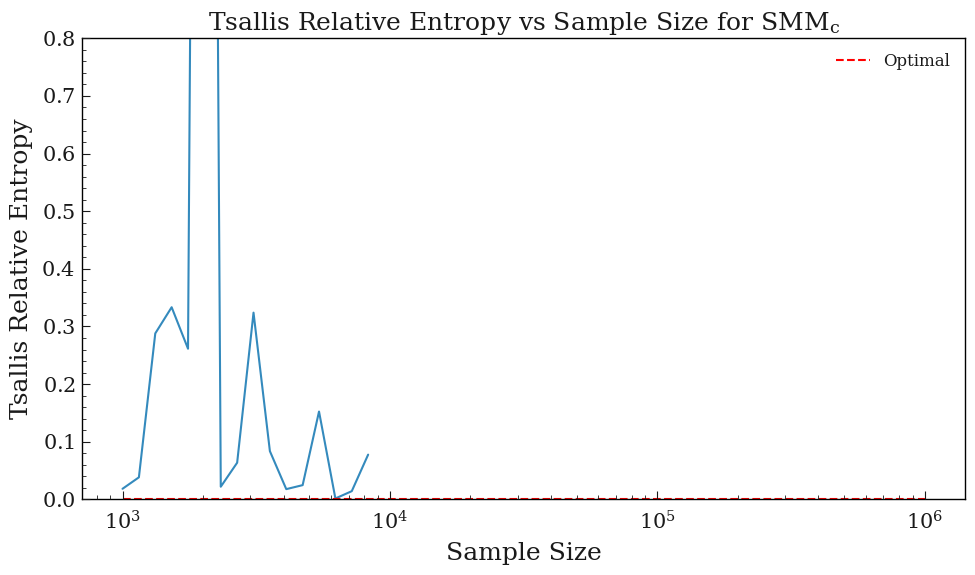

In [26]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)


#ax.plot([0,1],[optimal_divergence]*2, '--', c='red', label="Optimal")

ax.plot(sample_arr, mixture_div_arr)
ax.plot([sample_arr.min(),sample_arr.max()],[optimal_divergence]*2, '--', c='red', label="Optimal")

ax.set_ylim([-1e-5, 8e-1])
ax.legend()
ax.set_xlabel("Sample Size")
ax.set_ylabel("Tsallis Relative Entropy")
ax.set_title("Tsallis Relative Entropy vs Sample Size for $SMM_c$")
ax.set_xscale('log')
fig.tight_layout()
#fig.savefig("ts_vs_eta_basic_plot.pdf")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


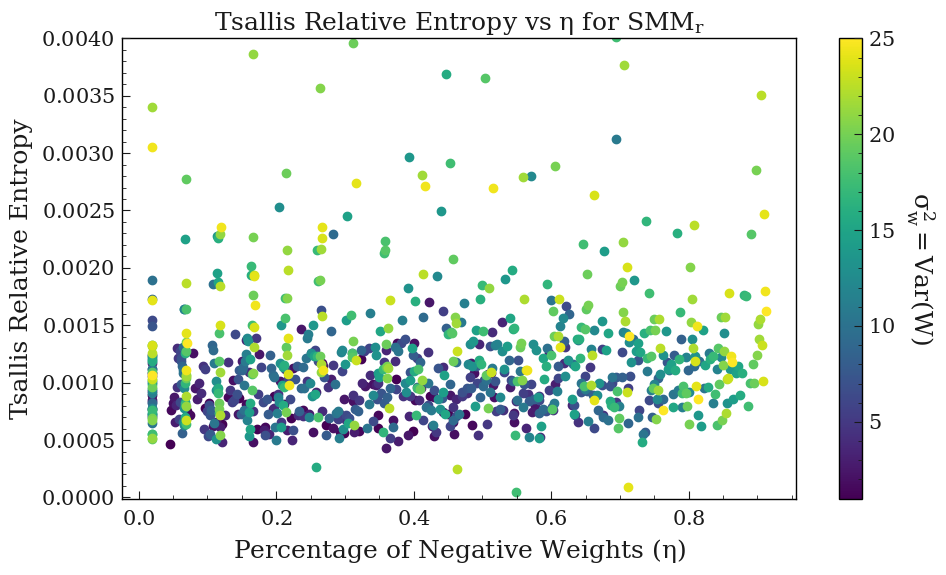

In [78]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_SIGMA))

for i in range(N_SIGMA):
    ax.scatter(eta_arr[i], mixture_div_arr[i], color=colors[i])

#ax.plot([0,1],[optimal_divergence]*2, '--', c='red', label="Optimal")

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=sigma_arr.min()**2, vmax=sigma_arr.max()**2),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("$\sigma_w^2 = Var(W)$", rotation=-90, va="bottom")

ax.set_ylim([-1e-5, 4e-3])
ax.legend()
ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_ylabel("Tsallis Relative Entropy")
ax.set_title("Tsallis Relative Entropy vs $\eta$ for $SMM_r$")
fig.tight_layout()
#fig.savefig("ts_vs_eta_mix_plot.pdf")

## Look at the divergence growth for the two types of models

0.000594152469187975 0.006852663269732191


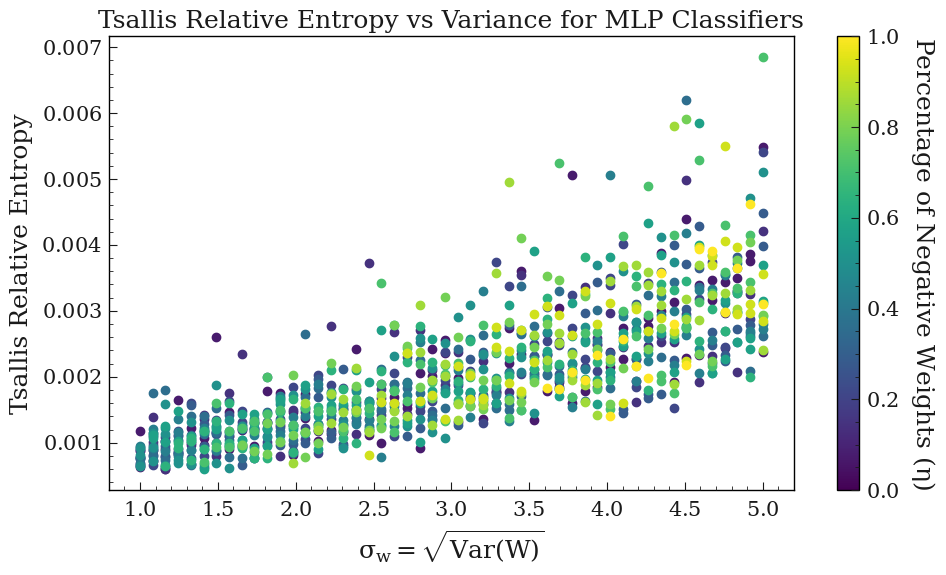

In [79]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(div_arr[~np.isnan(div_arr)], 1e-1),
                            np.percentile(div_arr[~np.isnan(div_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(div_arr[i,j]) and (div_arr[i,j] >= lower_bound) and (div_arr[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i])
            y_arr.append(div_arr[i,j])
            ax.scatter(sigma_arr[i], div_arr[i,j], color=color)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

ax.set_xlabel("$\sigma_w = \sqrt{Var(W)}$")
ax.set_ylabel("Tsallis Relative Entropy")
ax.set_title("Tsallis Relative Entropy vs Variance for MLP Classifiers")

#ax.set_ylim(top=2e-3)
fig.tight_layout()
fig.savefig("ts_vs_sigma_basic_plot.pdf")

0.000594152469187975 0.006852663269732191
Power Parameters: 7.60E-01, 2.40E-04, 6.67E-04


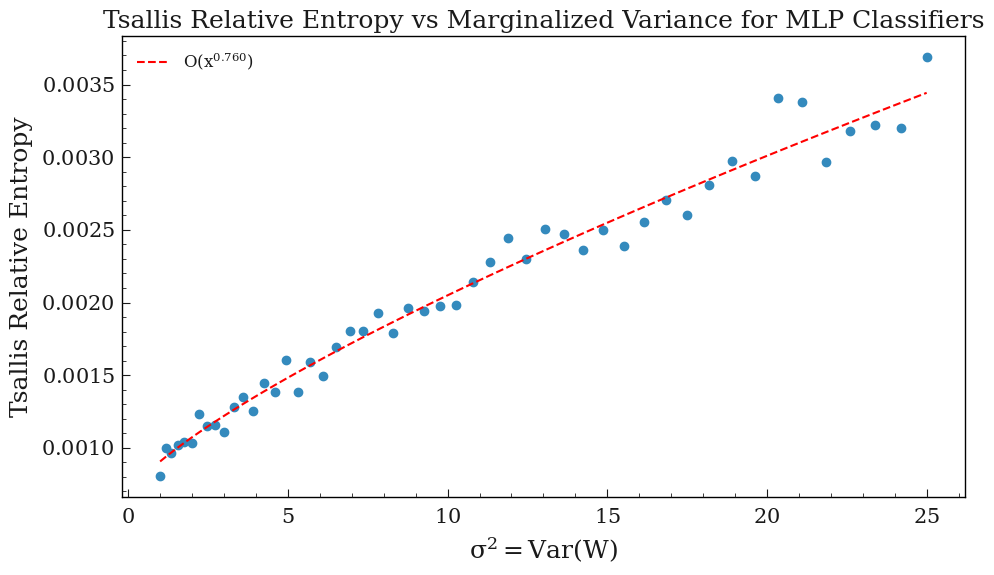

In [65]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(div_arr[~np.isnan(div_arr)], 1e-1),
                            np.percentile(div_arr[~np.isnan(div_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["cividis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_div_arr = np.copy(div_arr)
marginal_div_arr[(div_arr < lower_bound)|(div_arr > upper_bound)] = np.nan
marginal_div_arr = np.nanmean(marginal_div_arr, axis=1)
good_ix = ~np.isnan(marginal_div_arr)

ax.scatter(sigma_arr**2, marginal_div_arr)

power_p = lambda x, n, a,b: a*np.power(x, n) + b
power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix]**2, marginal_div_arr[good_ix], (1/2, 1, 0), maxfev=int(1e5))[0]

print("Power Parameters: {:.2E}, {:.2E}, {:.2E}".format(*power_params))

ax.plot(sigma_arr[good_ix]**2, power_p(sigma_arr[good_ix]**2, *power_params), '--', c='red', label="O$(x^{" +"{:.3f}".format(power_params[0])+"})$")

ax.legend()
ax.set_xlabel("$\sigma^2 = Var(W)$")
ax.set_ylabel("Tsallis Relative Entropy")
ax.set_title("Tsallis Relative Entropy vs Marginalized Variance for MLP Classifiers")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()

8.562388914288022e-05 0.0045


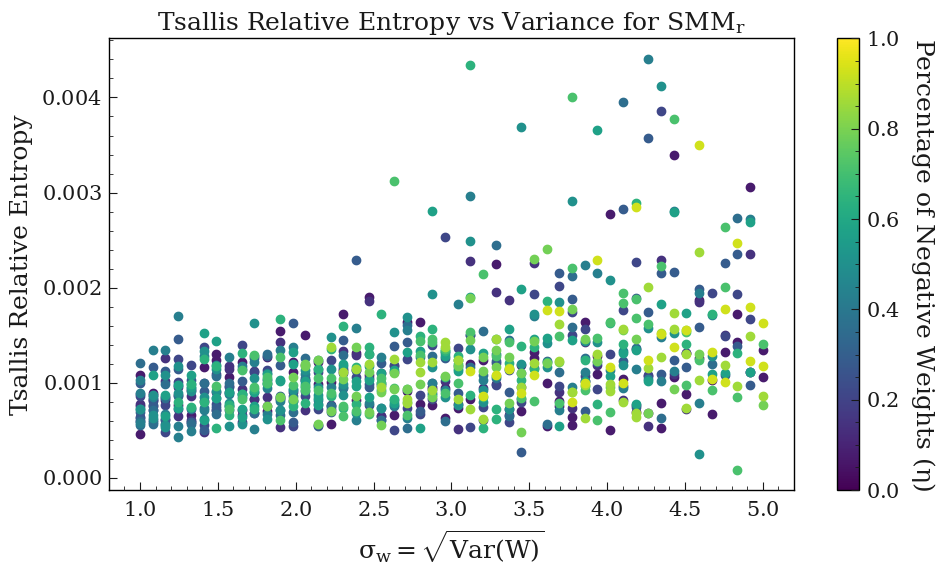

In [69]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
eta_search_list = np.linspace(0,1,N_COLORS)
x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 1e-1), 0.0045)
                            #np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 90))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        color = colors[np.searchsorted(eta_search_list, eta_arr[i,j])]
        if not np.isnan(mixture_div_arr[i,j]) and (mixture_div_arr[i,j] >= lower_bound) and (mixture_div_arr[i,j] <= upper_bound):
            x_arr.append(sigma_arr[i])
            y_arr.append(mixture_div_arr[i,j])
            ax.scatter(sigma_arr[i], mixture_div_arr[i,j], color=color)

#power_p = lambda x, a,b: a*x + b
#power_params = sp.optimize.curve_fit(power_p, x_arr, y_arr, (1, 0), maxfev=int(1e5))[0]
#ax.plot(sigma_arr, power_p(sigma_arr, *power_params), '--',  c='red', label="Linear Fit, R={:.3f}".format(np.corrcoef(x_arr, y_arr)[0,1]))

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=eta_search_list.min(), vmax=eta_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Percentage of Negative Weights ($\eta$)", rotation=-90, va="bottom")

#ax.legend(fontsize=15)
ax.set_xlabel("$\sigma_w = \sqrt{Var(W)}$")
ax.set_ylabel("Tsallis Relative Entropy")
ax.set_title("Tsallis Relative Entropy vs Variance for $SMM_r$")

#ax.set_ylim(top=2e-3)
fig.tight_layout()
fig.savefig("ts_vs_sigma_mix_plot.pdf")

8.562388914288022e-05 0.0045
Power Parameters: 4.98E-01, 2.02E-04, 5.97E-04


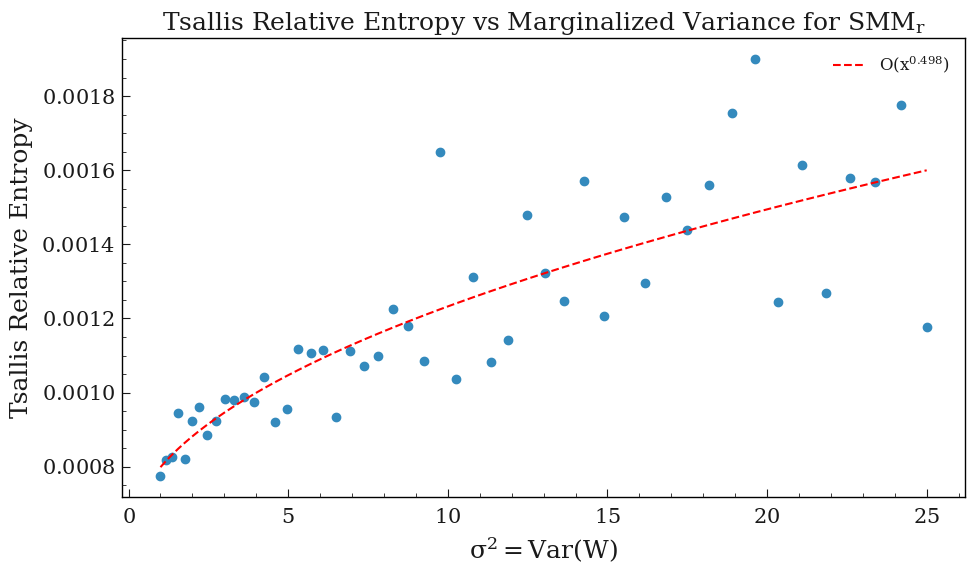

In [68]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

x_arr = []
y_arr = []

lower_bound, upper_bound = (np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 1e-1), 0.0045)
                            #np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 85))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_mixture_div_arr = np.copy(mixture_div_arr)
marginal_mixture_div_arr[(mixture_div_arr < lower_bound)|(mixture_div_arr > upper_bound)] = np.nan
marginal_mixture_div_arr = np.nanmean(marginal_mixture_div_arr, axis=1)
good_ix = ~np.isnan(marginal_mixture_div_arr)

ax.scatter(sigma_arr**2, marginal_mixture_div_arr)

power_p = lambda x, n, a,b: a*np.power(x, n) + b
power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix]**2, marginal_mixture_div_arr[good_ix], (1/2, 1, 0), maxfev=int(1e5))[0]

print("Power Parameters: {:.2E}, {:.2E}, {:.2E}".format(*power_params))

ax.plot(sigma_arr**2, power_p(sigma_arr**2, *power_params), '--',  c='red', label="O$(x^{" +"{:.3f}".format(power_params[0])+"})$")

ax.legend()
ax.set_xlabel("$\sigma^2 = Var(W)$")
ax.set_ylabel("Tsallis Relative Entropy")
ax.set_title("Tsallis Relative Entropy vs Marginalized Variance for $SMM_r$")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()

### Overlay both results. The Tsallis Entropy is computed on the radial coordinate reweighted data compared to the true target distribution

0.000594152469187975 0.006852663269732191
Basic Power Parameter: 0.7605, 2.40E-04, 6.67E-04
8.562388914288022e-05 0.0045
Mixture Power Parameters: 0.4976, 2.02E-04, 5.97E-04
[ 5.26249869e+00 -1.17974685e-13 -9.09415455e+01  6.11071551e-01]


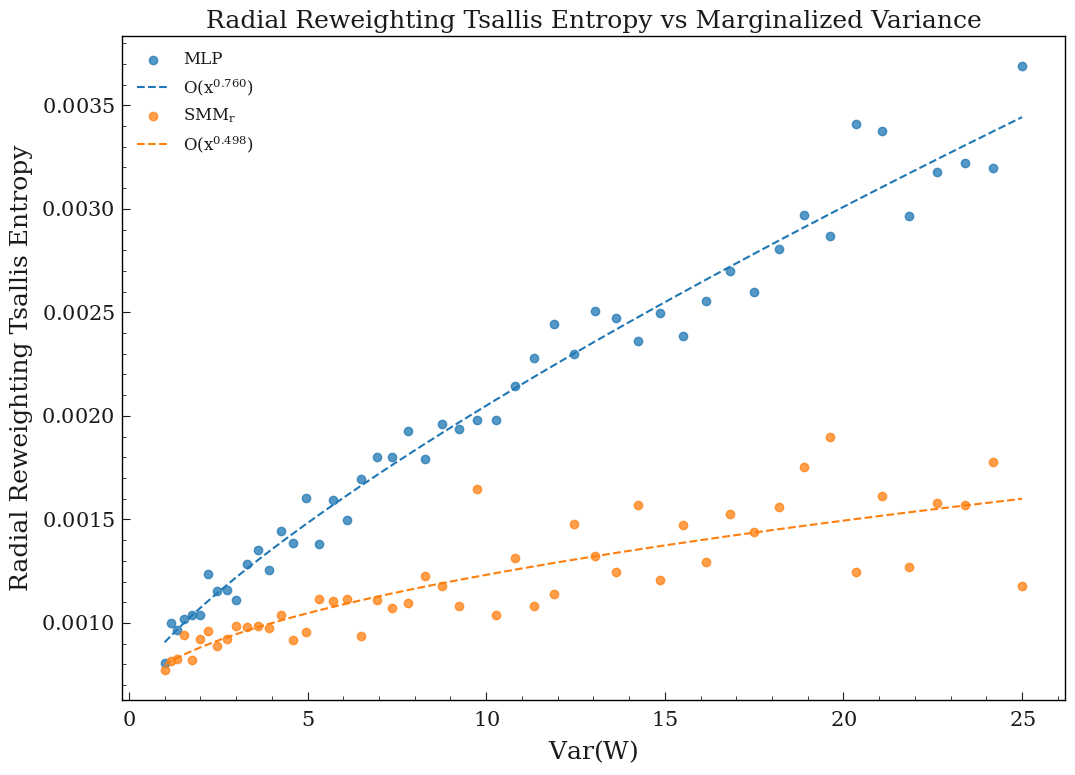

In [70]:
fig, ax = plt.subplots()
fig.set_size_inches(11,8)

lower_bound, upper_bound = (np.percentile(div_arr[~np.isnan(div_arr)], 1e-1),
                            np.percentile(div_arr[~np.isnan(div_arr)], 99.9))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["cividis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_div_arr = np.copy(div_arr)
marginal_div_arr[(div_arr < lower_bound)|(div_arr > upper_bound)] = np.nan
marginal_div_arr = np.nanmean(marginal_div_arr, axis=1)
good_ix = ~np.isnan(marginal_div_arr)

ax.scatter(sigma_arr**2, marginal_div_arr, c="tab:blue", alpha=0.75, label="MLP")

power_p = lambda x, n, a,b: a*np.power(x, n) + b
power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix]**2, marginal_div_arr[good_ix], (1/2, 1, 0), maxfev=int(1e5))[0]
print("Basic Power Parameter: {:.4f}, {:.2E}, {:.2E}".format(*power_params))

ax.plot(sigma_arr**2, power_p(sigma_arr**2, *power_params), '--', c='tab:blue', label="O$(x^{" +"{:.3f}".format(power_params[0])+"})$")


#######################

ax2 = ax

########################

lower_bound, upper_bound = (np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 1e-1), 0.0045)
                            #np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 90))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["cividis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_mixture_div_arr = np.copy(mixture_div_arr)
marginal_mixture_div_arr[(mixture_div_arr < lower_bound)|(mixture_div_arr > upper_bound)] = np.nan
marginal_mixture_div_arr = np.nanmean(marginal_mixture_div_arr, axis=1)
good_ix = ~np.isnan(marginal_mixture_div_arr)

ax2.scatter(sigma_arr**2, marginal_mixture_div_arr, c="tab:orange", alpha=0.75, label="$SMM_r$")

mixture_power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix]**2, marginal_mixture_div_arr[good_ix], (1/2, 1, 0), maxfev=int(1e5))[0]
print("Mixture Power Parameters: {:.4f}, {:.2E}, {:.2E}".format(*mixture_power_params))

ax2.plot(sigma_arr**2, power_p(sigma_arr**2, *mixture_power_params), '--', c='tab:orange', label="O$(x^{" +"{:.3f}".format(mixture_power_params[0])+"})$")
print(mixture_exp_params)


#ax.plot([sigma_arr.min()**2, sigma_arr.max()**2],[optimal_divergence]*2, '--', c='red', label="Optimal")


#lines, labels = ax.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
#ax2.legend(lines + lines2, labels + labels2)
ax.legend()

ax.set_xlabel("Var$(W)$")
ax.set_ylabel("Radial Reweighting Tsallis Entropy")
ax.set_title("Radial Reweighting Tsallis Entropy vs Marginalized Variance")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()
#fig.savefig("variance_growth_comparison.pdf")

0.000594152469187975 0.0052372842375189065
Basic Power Parameter: 0.7531, 2.29E-04, 6.60E-04
8.562388914288022e-05 0.0045
Mixture Power Parameters: 0.4852, 1.74E-04, 6.17E-04
[ 5.26249869e+00 -1.17974685e-13 -9.09415455e+01  6.11071551e-01]


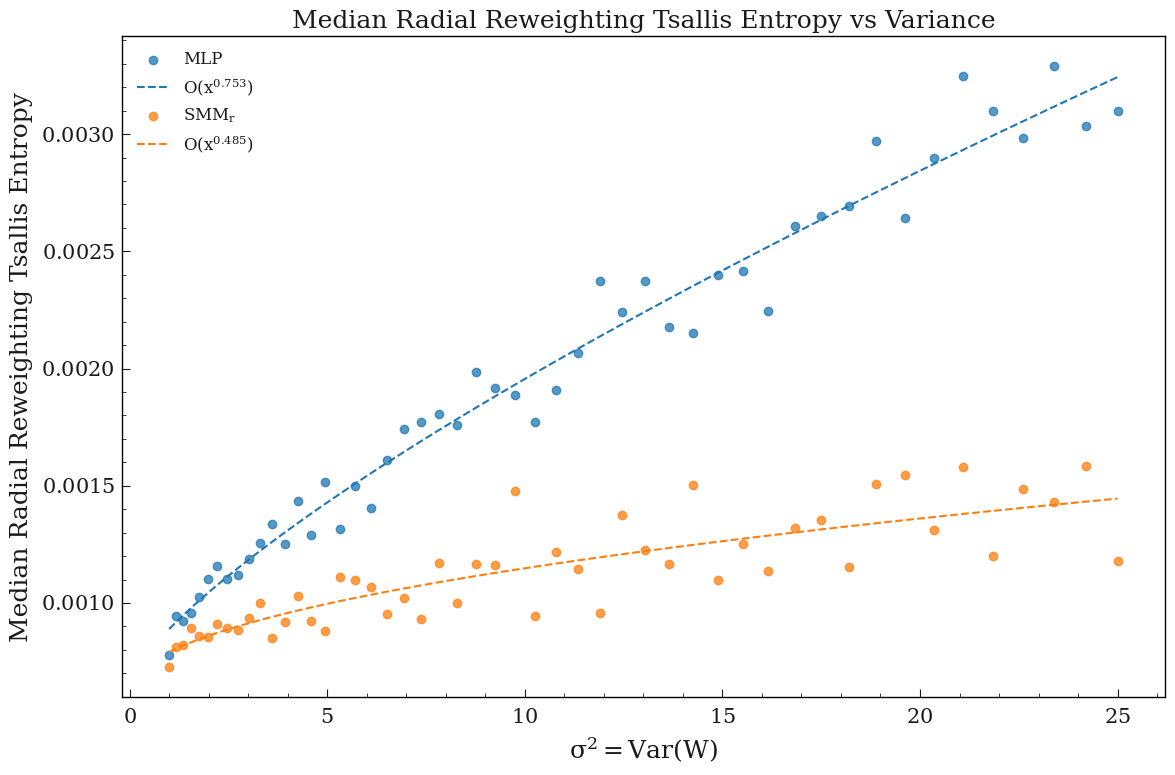

In [71]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)


lower_bound, upper_bound = (np.percentile(div_arr[~np.isnan(div_arr)], 1e-1),
                            np.percentile(div_arr[~np.isnan(div_arr)], 99))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_div_arr = np.copy(div_arr)
marginal_div_arr[(div_arr < lower_bound)|(div_arr > upper_bound)] = np.nan

marginal_div_arr = np.nanpercentile(marginal_div_arr, 50, axis=1)
good_ix = ~np.isnan(marginal_div_arr)

ax.scatter(sigma_arr**2, marginal_div_arr, c="tab:blue", alpha=0.75, label="MLP")

power_p = lambda x, n, a,b: a*np.power(x, n) + b
power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix]**2, marginal_div_arr[good_ix], (1/2, 1, 0), maxfev=int(1e5))[0]
print("Basic Power Parameter: {:.4f}, {:.2E}, {:.2E}".format(*power_params))

ax.plot(sigma_arr**2, power_p(sigma_arr**2, *power_params), '--', c='tab:blue', label="O$(x^{" +"{:.3f}".format(power_params[0])+"})$")


#######################

ax2 = ax

########################

lower_bound, upper_bound = (np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 1e-1), 0.0045)
                            #np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 93))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_mixture_div_arr = np.copy(mixture_div_arr)
marginal_mixture_div_arr[(mixture_div_arr < lower_bound)|(mixture_div_arr > upper_bound)] = np.nan

marginal_mixture_div_arr = np.nanpercentile(marginal_mixture_div_arr, 50, axis=1)
good_ix = ~np.isnan(marginal_mixture_div_arr)
#good_ix[-1] = False

ax2.scatter(sigma_arr**2, marginal_mixture_div_arr, c="tab:orange", alpha=0.75, label="$SMM_r$")

mixture_power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix]**2, marginal_mixture_div_arr[good_ix], (1/2, 1, 0), maxfev=int(1e5))[0]
print("Mixture Power Parameters: {:.4f}, {:.2E}, {:.2E}".format(*mixture_power_params))

ax2.plot(sigma_arr**2, power_p(sigma_arr**2, *mixture_power_params), '--', c='tab:orange', label="O$(x^{" +"{:.3f}".format(mixture_power_params[0])+"})$")
print(mixture_exp_params)


#ax.plot([sigma_arr.min()**2, sigma_arr.max()**2],[optimal_divergence]*2, '--', c='red', label="Optimal")


#lines, labels = ax.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
#ax2.legend(lines + lines2, labels + labels2)
ax.legend()

ax.set_xlabel("$\sigma^2 = Var(W)$")
ax.set_ylabel("Median Radial Reweighting Tsallis Entropy")
ax.set_title("Median Radial Reweighting Tsallis Entropy vs Variance")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()
fig.savefig("divergence_vs_variance_growth_comparison.pdf")

0.000594152469187975 0.0052372842375189065
Basic Power Parameter: 5.93E-04, 1.48E-04
8.562388914288022e-05 0.0045
Mixture Power Parameters: 0.0002, 6.30E-04
[0.00016345 0.0006301 ]
Ratio: 3.630332888619353


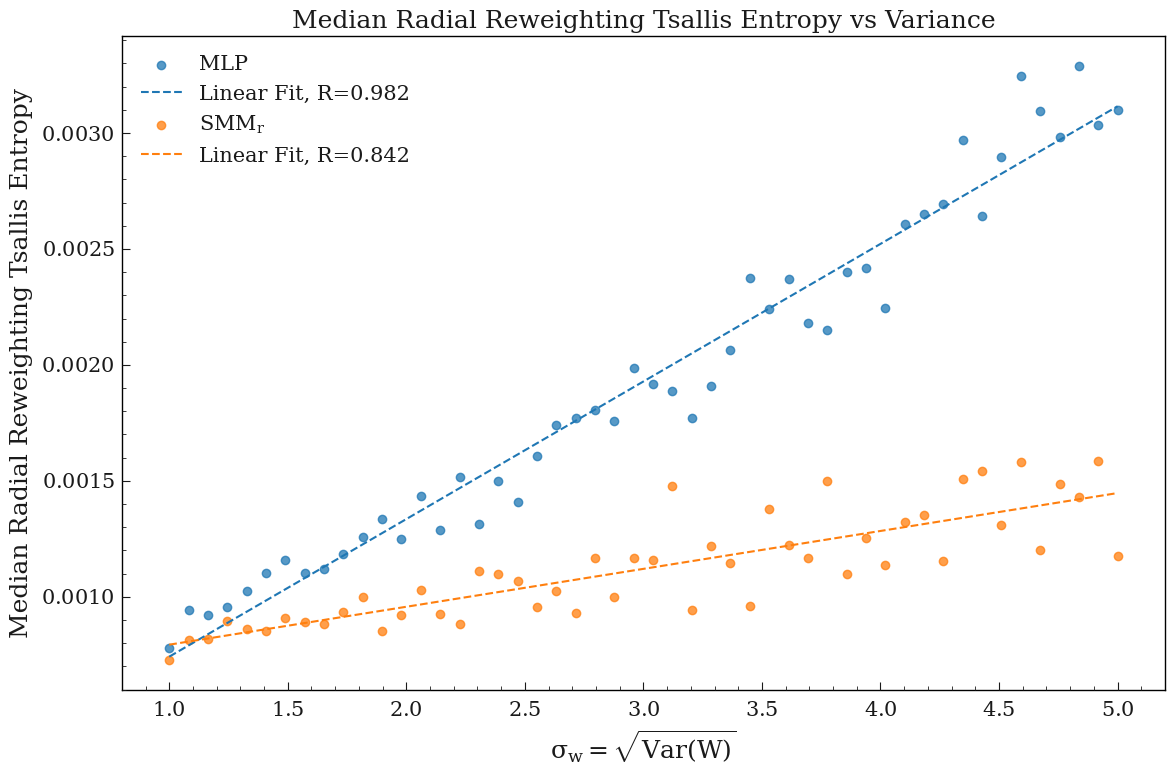

In [75]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)


lower_bound, upper_bound = (np.percentile(div_arr[~np.isnan(div_arr)], 1e-1),
                            np.percentile(div_arr[~np.isnan(div_arr)], 99))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_div_arr = np.copy(div_arr)
marginal_div_arr[(div_arr < lower_bound)|(div_arr > upper_bound)] = np.nan

marginal_div_arr = np.nanpercentile(marginal_div_arr, 50, axis=1)
good_ix = ~np.isnan(marginal_div_arr)

ax.scatter(sigma_arr, marginal_div_arr, c="tab:blue", alpha=0.75, label="MLP")

power_p = lambda x, a,b: a*x + b
power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix], marginal_div_arr[good_ix], (1, 0), maxfev=int(1e5))[0]
print("Basic Power Parameter: {:.2E}, {:.2E}".format(*power_params))

#ax.plot(sigma_arr, power_p(sigma_arr, *power_params), '--', c='tab:blue', label="O$(x^{" +"{:.3f}".format(power_params[0])+"})$")
#ax.plot(sigma_arr, power_p(sigma_arr, *power_params), '--', c='tab:blue', label="$O(x)$ Fit".format(*power_params))
ax.plot(sigma_arr, power_p(sigma_arr, *power_params), '--', c='tab:blue', label="Linear Fit, R={:.3f}".format(np.corrcoef(sigma_arr[good_ix], marginal_div_arr[good_ix])[0,1]))

#######################

ax2 = ax

########################

lower_bound, upper_bound = (np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 1e-1), 0.0045)
                            #np.percentile(mixture_div_arr[~np.isnan(mixture_div_arr)], 93))
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

marginal_mixture_div_arr = np.copy(mixture_div_arr)
marginal_mixture_div_arr[(mixture_div_arr < lower_bound)|(mixture_div_arr > upper_bound)] = np.nan

marginal_mixture_div_arr = np.nanpercentile(marginal_mixture_div_arr, 50, axis=1)
good_ix = ~np.isnan(marginal_mixture_div_arr)
#good_ix[-1] = False

ax2.scatter(sigma_arr, marginal_mixture_div_arr, c="tab:orange", alpha=0.75, label="$SMM_r$")

mixture_power_params = sp.optimize.curve_fit(power_p, sigma_arr[good_ix], marginal_mixture_div_arr[good_ix], (1, 0), maxfev=int(1e5))[0]
print("Mixture Power Parameters: {:.4f}, {:.2E}".format(*mixture_power_params))

#ax.plot([], [], ' ', label="$R = {:.3f}$".format(np.corrcoef(x_arr,y_arr)[0,1]))
ax2.plot(sigma_arr, power_p(sigma_arr, *mixture_power_params), '--', c='tab:orange', label="Linear Fit, R={:.3f}".format(np.corrcoef(sigma_arr[good_ix], marginal_mixture_div_arr[good_ix])[0,1]))
print(mixture_power_params)

print("Ratio:", power_params[0]/mixture_power_params[0])

#ax.plot([sigma_arr.min()**2, sigma_arr.max()**2],[optimal_divergence]*2, '--', c='red', label="Optimal")


#lines, labels = ax.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
#ax2.legend(lines + lines2, labels + labels2)
ax.legend(fontsize=15)

ax.set_xlabel("$\sigma_w = \sqrt{Var(W)}$")
ax.set_ylabel("Median Radial Reweighting Tsallis Entropy")
ax.set_title("Median Radial Reweighting Tsallis Entropy vs Variance")

#ax.set_ylim([-2e-8, 2e-7])
fig.tight_layout()
fig.savefig("divergence_vs_variance_growth_comparison.pdf")

0.0005941524691879752 0.005237284237518909


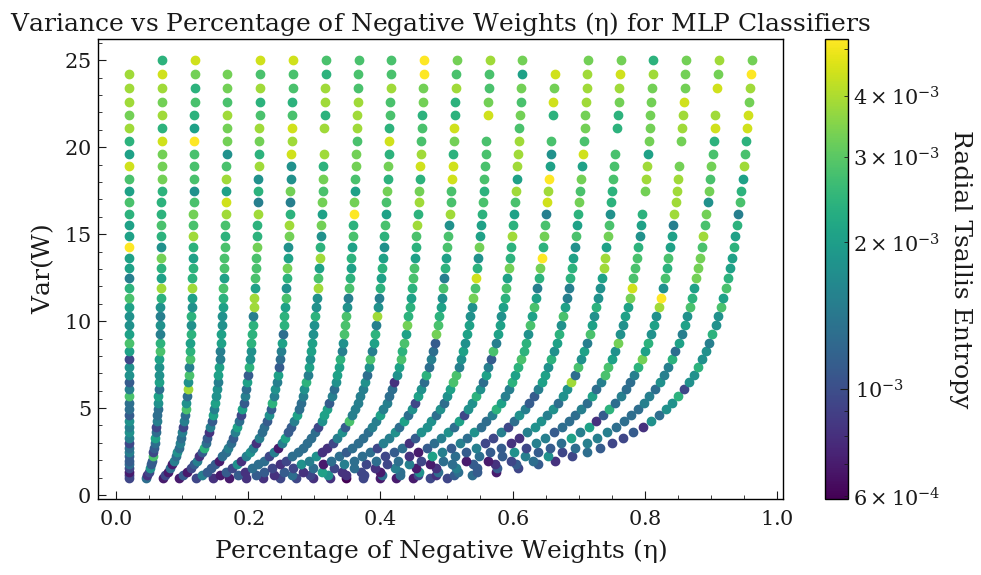

In [73]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15
div_search_list = np.logspace(np.log10(np.nanpercentile(div_arr, 1e-1)),
                              np.log10(np.nanpercentile(div_arr, 99)),
                              N_COLORS)
#div_search_list = np.linspace(np.nanpercentile(div_arr, 1e-1),
#                              np.nanpercentile(div_arr, 99),
#                              N_COLORS)


lower_bound, upper_bound = (div_search_list.min(), div_search_list.max())
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        search_ix = np.searchsorted(div_search_list, div_arr[i,j])
        if search_ix >= N_COLORS:
            continue
        color = colors[search_ix]
        if not np.isnan(div_arr[i,j]):# and (div_arr[i,j] >= lower_bound) and (div_arr[i,j] <= upper_bound):
            ax.scatter(eta_arr[i,j], sigma_arr[i]**2, color=color)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.LogNorm(vmin=div_search_list.min(), vmax=div_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Radial Tsallis Entropy", rotation=-90, va="bottom")

ax.set_ylabel("Var$(W)$")
ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_title("Variance vs Percentage of Negative Weights ($\eta$) for MLP Classifiers")

#ax.set_ylim(top=2e-3)
fig.tight_layout()

0.0005941524691879752 0.004499999999999998


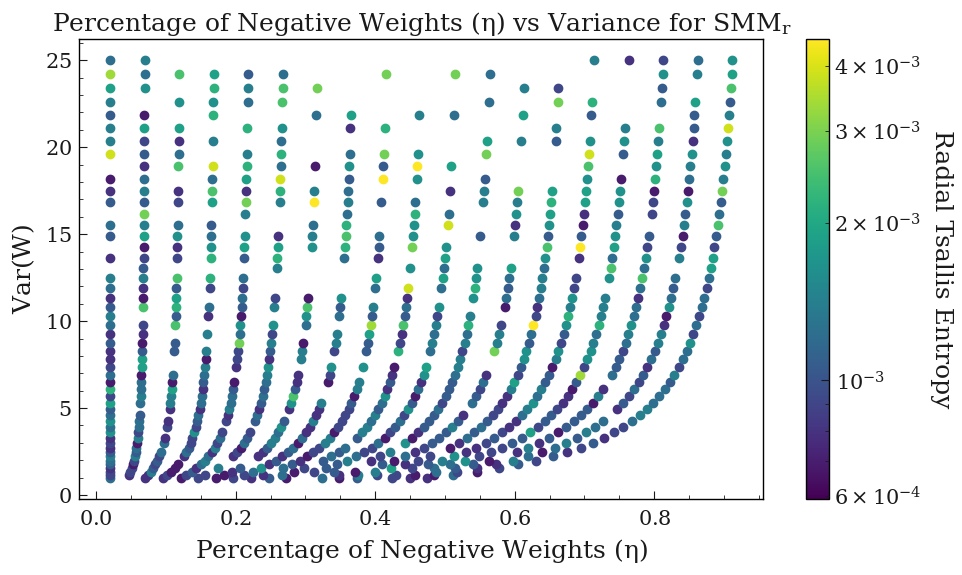

In [74]:
fig, ax = plt.subplots()
fig.set_size_inches(10,6)

N_COLORS = 15

div_search_list = np.logspace(np.log10(np.nanpercentile(div_arr, 1e-1)),
                              np.log10(0.0045),
                              N_COLORS)

#div_search_list = np.linspace(np.nanpercentile(mixture_div_arr, 1e-1),
#                              0.0045,
#                              N_COLORS)


lower_bound, upper_bound = (div_search_list.min(), div_search_list.max())
print(lower_bound, upper_bound)

cmap = mpl.colormaps["viridis"]
colors = cmap(np.linspace(0,1,N_COLORS))

for i in range(N_SIGMA):
    for j in range(N_ETA):
        search_ix = np.searchsorted(div_search_list, mixture_div_arr[i,j])
        if search_ix >= N_COLORS:
            continue
        color = colors[search_ix]
        if not np.isnan(mixture_div_arr[i,j]) and (mixture_div_arr[i,j] >= lower_bound) and (mixture_div_arr[i,j] <= upper_bound):
            #y_arr.append(sigma_arr[i]**2)
            #x_arr.append(eta_arr[i,j])
            ax.scatter(eta_arr[i,j], sigma_arr[i]**2, color=color)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.LogNorm(vmin=div_search_list.min(), vmax=div_search_list.max()),
                                          cmap=cmap),
                    ax=ax)
cbar.ax.set_ylabel("Radial Tsallis Entropy", rotation=-90, va="bottom")

ax.set_ylabel("Var$(W)$")
ax.set_xlabel("Percentage of Negative Weights ($\eta$)")
ax.set_title("Percentage of Negative Weights ($\eta$) vs Variance for $SMM_r$")

#ax.set_ylim(top=2e-3)
fig.tight_layout()

### Let's look at correlation coefficients

In [287]:
data_arr = []

for i in range(N_SIGMA):
    for j in range(N_ETA):
        if np.isnan(div_arr[i,j]):
            continue
        data_arr.append([sigma_arr[i], eta_arr[i,j], div_arr[i,j]])

# sigma, eta, div
corrcoef = np.corrcoef(data_arr, rowvar=False)
corrcoef

array([[1.        , 0.20660415, 0.77119058],
       [0.20660415, 1.        , 0.17940606],
       [0.77119058, 0.17940606, 1.        ]])

In [288]:
data_arr = []

for i in range(N_SIGMA):
    for j in range(N_ETA):
        if np.isnan(mixture_div_arr[i,j]) or mixture_div_arr[i,j] > 0.0045:
            continue
        data_arr.append([sigma_arr[i], eta_arr[i,j], mixture_div_arr[i,j]])

# sigma, eta, div
mixture_corrcoef = np.corrcoef(data_arr, rowvar=False)
mixture_corrcoef

array([[1.        , 0.21100092, 0.41401097],
       [0.21100092, 1.        , 0.10253317],
       [0.41401097, 0.10253317, 1.        ]])

### Now look at mutual information (code from [S. Do.](https://medium.com/latinxinai/computing-mutual-information-matrix-with-python-6ced9169bcb1))

In [246]:
import pandas as pd

def joint_entropies(data, nbins=None):
    n_variables = data.shape[-1]
    n_samples = data.shape[0]
    if nbins == None:
        nbins = int((n_samples/5)**.5)
    histograms2d = np.zeros((n_variables, n_variables, nbins, nbins))
    for i in range(n_variables):
        for j in range(n_variables):
            histograms2d[i,j] = np.histogram2d(data[:,i], data[:,j], bins=nbins)[0]
    probs = histograms2d / len(data) + 1e-100
    joint_entropies = -(probs * np.log2(probs)).sum((2,3))
    return joint_entropies

def mutual_info_matrix(df, nbins=None, normalized=True):
    data = df.to_numpy()
    n_variables = data.shape[-1]
    j_entropies = joint_entropies(data, nbins)
    entropies = j_entropies.diagonal()
    entropies_tile = np.tile(entropies, (n_variables, 1))
    sum_entropies = entropies_tile + entropies_tile.T
    mi_matrix = sum_entropies - j_entropies
    if normalized:
        mi_matrix = mi_matrix * 2 / sum_entropies    
    return pd.DataFrame(mi_matrix, index=df.columns, columns=df.columns)

In [255]:
data_arr = []

for i in range(N_SIGMA):
    for j in range(N_ETA):
        if np.isnan(div_arr[i,j]):
            continue
        data_arr.append([sigma_arr[i], eta_arr[i,j], div_arr[i,j]])

data_df = pd.DataFrame(data_arr, columns=["$\sigma$", "$\eta$", "Tsallis Entropy"])
print("Mutual Information Matrix for the Basic Model")
mutual_info_matrix(data_df)

Mutual Information Matrix for the Basic Model


,$\sigma$,$\eta$,Tsallis Entropy
$\sigma$,1.00000,0.040060,0.249760
$\eta$,0.04006,1.000000,0.040063
Tsallis Entropy,0.24976,0.040063,1.000000


In [289]:
data_arr = []

for i in range(N_SIGMA):
    for j in range(N_ETA):
        if np.isnan(mixture_div_arr[i,j]) or mixture_div_arr[i,j] > 0.0045:
            continue
        data_arr.append([sigma_arr[i], eta_arr[i,j], mixture_div_arr[i,j]])

data_df = pd.DataFrame(data_arr, columns=["$\sigma$", "$\eta$", "Tsallis Entropy"])
print("Mutual Information Matrix for the SMM+ Model")
mutual_info_matrix(data_df)

Mutual Information Matrix for the SMM+ Model


,$\sigma$,$\eta$,Tsallis Entropy
$\sigma$,1.000000,0.049621,0.080649
$\eta$,0.049621,1.000000,0.042672
Tsallis Entropy,0.080649,0.042672,1.000000
